In [ ]:
import numpy as np

# Ages only
ages = np.array([64, 53, 55, 58, 66, 74, 67, 61], dtype=float)

# Mean and sample standard deviation
mean_age = np.mean(ages)
std_age = np.std(ages, ddof=1)  # ddof=1 for sample standard deviation

print(f"Mean age = {mean_age:.2f}")
print(f"Standard deviation = {std_age:.2f}")


Mean age = 62.25
Standard deviation = 6.92


In [ ]:
import pandas as pd

# List of CSV files to concatenate (assumes they're in the same directory)
csv_files = ['/content/S1Data (3).csv','/content/S2Data.csv','/content/S3Data.csv','/content/S4Data.csv','/content/S5Data.csv','/content/S6Data.csv','/content/S7Data.csv','/content/S8Data.csv']

# Read and concatenate
df_combined = pd.concat([pd.read_csv(file) for file in csv_files], ignore_index=True)




# Optional: Save to new file
df_combined.to_csv('combined_output.csv', index=False)

# Confirm it's combined
print(f"Combined shape: {df_combined.shape}")
df_combined


Combined shape: (115, 29)


,day,lowest_heart_rate,avg_brs,subject_no,total_sleep_duration,time_in_bed,restless_periods,rem_sleep_duration,light_sleep_duration,deep_sleep_duration,...,Total No-Go Trials,Correct No-Go Trials,Avg RT Correct No-Go (ms),active_calories,average_met_minutes,equivalent_walking_distance,high_activity_met_minutes,high_activity_time,steps,total_calories
0,2025-05-16,64.0,3.333333,1.0,25200.0,33420.0,171.0,3420.0,17820.0,3960.0,...,15.0,1.0,1336.7,632.0,1.62500,12258.0,28.0,240.0,10658.0,2641.0
1,2025-05-17,68.0,3.333333,1.0,27630.0,33055.0,151.0,6780.0,15180.0,5670.0,...,15.0,1.0,1273.3,653.0,1.59375,13045.0,36.0,300.0,11109.0,2618.0
2,2025-05-20,68.0,3.333333,1.0,22410.0,26340.0,115.0,2910.0,15360.0,4140.0,...,15.0,1.0,1320.0,553.0,1.56250,11193.0,21.0,180.0,7599.0,2550.0
3,2025-05-21,63.0,3.333333,1.0,28950.0,32160.0,204.0,4770.0,19710.0,4470.0,...,15.0,1.0,1336.7,478.0,1.50000,9577.0,16.0,120.0,6099.0,2455.0
4,2025-05-22,60.0,3.333333,1.0,23790.0,33000.0,147.0,5520.0,12720.0,5550.0,...,15.0,1.0,1310.0,647.0,1.62500,13407.0,16.0,120.0,9350.0,2656.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,2025-08-10,57.0,3.833333,8.0,32490.0,36720.0,128.0,7650.0,19380.0,5460.0,...,15.0,1.0,1373.3,528.0,1.53125,10643.0,21.0,180.0,8062.0,2516.0
111,2025-08-12,54.0,3.833333,8.0,22980.0,25620.0,91.0,5160.0,11730.0,6090.0,...,15.0,1.0,1356.7,567.0,1.59375,11506.0,22.0,180.0,7798.0,2584.0
112,2025-08-12,54.0,3.833333,8.0,22980.0,25620.0,91.0,5160.0,11730.0,6090.0,...,15.0,1.0,1356.7,567.0,1.59375,11506.0,22.0,180.0,7798.0,2584.0
113,2025-08-12,54.0,3.833333,8.0,22980.0,25620.0,91.0,5160.0,11730.0,6090.0,...,15.0,1.0,1333.3,567.0,1.59375,11506.0,22.0,180.0,7798.0,2584.0


In [ ]:
df_combined[df_combined.columns[df_combined.isnull().any()]]

""
0
1
2
3
4
...
110
111
112
113


In [ ]:
import pandas as pd

# Define your features and targets
features_1 = ['lowest_heart_rate','avg_brs','total_sleep_duration','time_in_bed','restless_periods', 'rem_sleep_duration' , 'light_sleep_duration','deep_sleep_duration' , 'efficiency' , 'average_heart_rate','average_breath','average_hrv']


# Assuming your DataFrame is named df and has a 'date' and 'subject_no' column
# Make sure the date column is in datetime format
df_combined['day'] = pd.to_datetime(df_combined['day'])



# Sort values to prepare for rolling operation
df_sort = df_combined.sort_values(by=['subject_no', 'day'])

# Set the rolling window size
window_size = 5

# Compute rolling averages for each feature, grouped by subject
for feature in features_1:
    df_sort[f'{feature}_rollavg'] = (
        df_sort.groupby('subject_no')[feature]
        .rolling(window=window_size, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )


In [ ]:
df_combined.columns

Index(['day', 'lowest_heart_rate', 'avg_brs', 'subject_no',
       'total_sleep_duration', 'time_in_bed', 'restless_periods',
       'rem_sleep_duration', 'light_sleep_duration', 'deep_sleep_duration',
       'hrv', 'efficiency', 'average_hrv', 'average_heart_rate',
       'average_breath', 'Date and Time', 'Total Go Trials',
       'Correct Go Trials', 'Avg RT Correct Go (ms)', 'Total No-Go Trials',
       'Correct No-Go Trials', 'Avg RT Correct No-Go (ms)', 'active_calories',
       'average_met_minutes', 'equivalent_walking_distance',
       'high_activity_met_minutes', 'high_activity_time', 'steps',
       'total_calories'],
      dtype='object')

In [ ]:
df_sort.isna().sum()

,0
day,0
lowest_heart_rate,0
avg_brs,0
subject_no,0
total_sleep_duration,0
time_in_bed,0
restless_periods,0
rem_sleep_duration,0
light_sleep_duration,0
deep_sleep_duration,0


In [ ]:
df_combined = df_sort.copy()

In [ ]:
df_combined.isna().sum()


,0
day,0
lowest_heart_rate,0
avg_brs,0
subject_no,0
total_sleep_duration,0
time_in_bed,0
restless_periods,0
rem_sleep_duration,0
light_sleep_duration,0
deep_sleep_duration,0


In [ ]:
df_combined.columns

Index(['day', 'lowest_heart_rate', 'avg_brs', 'subject_no',
       'total_sleep_duration', 'time_in_bed', 'restless_periods',
       'rem_sleep_duration', 'light_sleep_duration', 'deep_sleep_duration',
       'hrv', 'efficiency', 'average_hrv', 'average_heart_rate',
       'average_breath', 'Date and Time', 'Total Go Trials',
       'Correct Go Trials', 'Avg RT Correct Go (ms)', 'Total No-Go Trials',
       'Correct No-Go Trials', 'Avg RT Correct No-Go (ms)', 'active_calories',
       'average_met_minutes', 'equivalent_walking_distance',
       'high_activity_met_minutes', 'high_activity_time', 'steps',
       'total_calories', 'lowest_heart_rate_rollavg', 'avg_brs_rollavg',
       'total_sleep_duration_rollavg', 'time_in_bed_rollavg',
       'restless_periods_rollavg', 'rem_sleep_duration_rollavg',
       'light_sleep_duration_rollavg', 'deep_sleep_duration_rollavg',
       'efficiency_rollavg', 'average_heart_rate_rollavg',
       'average_breath_rollavg', 'average_hrv_rollavg'],
   

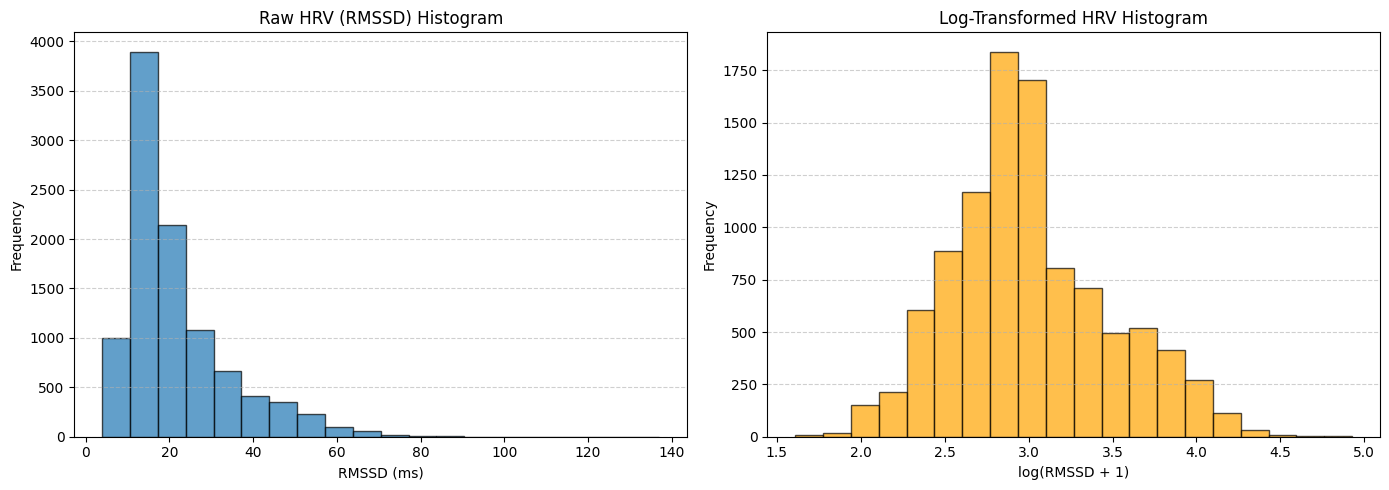

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast

# -----------------------------
# Assuming df_combined already exists and has your HRV column
hrv_col = "hrv"

# Parse HRV string-lists into real Python lists
df_combined["_hrv_parsed"] = df_combined[hrv_col].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else []
)

# Flatten all HRV values into one list
all_hrv_values = [val for sublist in df_combined["_hrv_parsed"] for val in sublist]

# -----------------------------
# Apply log transformation (log1p handles zero safely: log(x+1))
log_hrv_values = np.log1p(all_hrv_values)

# -----------------------------
# Plot side-by-side comparison
plt.figure(figsize=(14, 5))

# Raw histogram
plt.subplot(1, 2, 1)
plt.hist(all_hrv_values, bins=20, edgecolor="black", alpha=0.7)
plt.title("Raw HRV (RMSSD) Histogram")
plt.xlabel("RMSSD (ms)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Log-transformed histogram
plt.subplot(1, 2, 2)
plt.hist(log_hrv_values, bins=20, edgecolor="black", alpha=0.7, color="orange")
plt.title("Log-Transformed HRV Histogram")
plt.xlabel("log(RMSSD + 1)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import ast

# ---- CONFIG: update if your column names differ ----
HRV_LIST_COL = "hrv"           # column that has strings like "[15, 22, ...]"
PARSED_COL   = "_hrv_parsed"   # if you already created parsed lists, leave this

# ---- 1) Collect raw RMSSD values as one flat list ----
def _get_all_hrv(df):
    if PARSED_COL in df.columns:
        lists = df[PARSED_COL].tolist()
    elif HRV_LIST_COL in df.columns:
        # parse the string lists on the fly
        lists = df[HRV_LIST_COL].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else []).tolist()
    else:
        raise ValueError(f"Could not find '{PARSED_COL}' or '{HRV_LIST_COL}' in df_combined.")
    return [v for sub in lists for v in sub if pd.notna(v)]

# Expecting your df to be called df_combined
all_hrv_values = _get_all_hrv(df_combined)

# Safety: drop negatives, keep finite
all_hrv_values = [float(x) for x in all_hrv_values if np.isfinite(x) and x >= 0]

# ---- 2) Log-transform ----
log_hrv = np.log1p(all_hrv_values)  # log(RMSSD + 1)

# ---- 3) Descriptive stats on log scale ----
n = len(log_hrv)
mean_log = float(np.mean(log_hrv))
sd_log   = float(np.std(log_hrv, ddof=1))
median_log = float(np.median(log_hrv))
skew_log   = float(stats.skew(log_hrv, bias=False))
kurt_excess_log = float(stats.kurtosis(log_hrv, bias=False))

# Normality tests (note: Shapiro is best for n<=5000; K^2 works for larger too)
shapiro_W, shapiro_p = stats.shapiro(log_hrv) if n <= 5000 else (np.nan, np.nan)
k2_stat, k2_p = stats.normaltest(log_hrv)

# ---- 4) Back-transform key summaries to ms ----
geo_mean_ms   = float(np.expm1(mean_log))     # geometric mean
median_ms     = float(np.expm1(median_log))   # back-transformed median
geo_sd_factor = float(np.exp(sd_log))         # ×/÷ factor for 1 SD on the log scale

# Percentiles
pcts = [5, 25, 50, 75, 95]
pct_logs = np.percentile(log_hrv, pcts)
pct_ms   = np.expm1(pct_logs)

# ---- 5) Assemble results ----
rows = [
    ("N", n),
    ("Mean (log)", mean_log),
    ("SD (log)", sd_log),
    ("Median (log)", median_log),
    ("Skewness (log)", skew_log),
    ("Excess Kurtosis (log)", kurt_excess_log),
    ("Shapiro W", shapiro_W),
    ("Shapiro p", shapiro_p),
    ("D'Agostino K²", k2_stat),
    ("K² p", k2_p),
    ("Geometric Mean (ms)", geo_mean_ms),
    ("Median (ms)", median_ms),
    ("Geo SD factor (×/÷)", geo_sd_factor),
    ("P5 (ms)", float(pct_ms[0])),
    ("P25 (ms)", float(pct_ms[1])),
    ("P50 (ms)", float(pct_ms[2])),
    ("P75 (ms)", float(pct_ms[3])),
    ("P95 (ms)", float(pct_ms[4])),
]

summary = pd.DataFrame(rows, columns=["Metric", "Value"])
print(summary.to_string(index=False))

# ---- 6) Handy interpretive strings you can paste in a report ----
lo68 = geo_mean_ms / geo_sd_factor
hi68 = geo_mean_ms * geo_sd_factor
print("\nInterpretation tips:")
print(f"- Geometric mean HRV ≈ {geo_mean_ms:.1f} ms.")
print(f"- ~68% of nights lie between ~{lo68:.1f} and ~{hi68:.1f} ms (using the geometric SD factor ×{geo_sd_factor:.2f}).")
print(f"- Central band (IQR) ≈ {pct_ms[1]:.1f}–{pct_ms[3]:.1f} ms; median = {median_ms:.1f} ms.")
if not np.isnan(shapiro_p):
    print(f"- Normality (Shapiro): p = {shapiro_p:.3g} (>{0.05} means not significantly different from normal).")
print(f"- Normality (D'Agostino K²): p = {k2_p:.3g}.")


               Metric         Value
                    N  9.966000e+03
           Mean (log)  2.999826e+00
             SD (log)  4.791937e-01
         Median (log)  2.944439e+00
       Skewness (log)  4.716747e-01
Excess Kurtosis (log) -6.640404e-02
            Shapiro W           NaN
            Shapiro p           NaN
        D'Agostino K²  3.368471e+02
                 K² p  7.154614e-74
  Geometric Mean (ms)  1.908205e+01
          Median (ms)  1.800000e+01
  Geo SD factor (×/÷)  1.614772e+00
              P5 (ms)  9.000000e+00
             P25 (ms)  1.400000e+01
             P50 (ms)  1.800000e+01
             P75 (ms)  2.600000e+01
             P95 (ms)  4.900000e+01

Interpretation tips:
- Geometric mean HRV ≈ 19.1 ms.
- ~68% of nights lie between ~11.8 and ~30.8 ms (using the geometric SD factor ×1.61).
- Central band (IQR) ≈ 14.0–26.0 ms; median = 18.0 ms.
- Normality (D'Agostino K²): p = 7.15e-74.


LOG scale  ->  mean=3.000, median=2.944, mode≈2.854
Back to ms ->  mean≈19.1 ms, median≈18.0 ms, mode≈16.4 ms


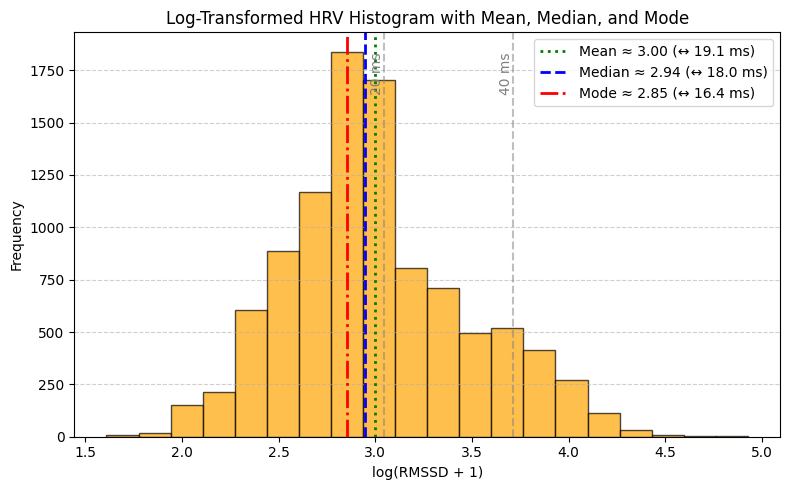

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast

# -------- Parse HRV list-strings and flatten to raw values --------
hrv_col = "hrv"
df_combined["_hrv_parsed"] = df_combined[hrv_col].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else []
)
all_hrv_values = [v for sub in df_combined["_hrv_parsed"] for v in sub]

# -------- Log-transform --------
log_vals = np.log1p(all_hrv_values)  # log(RMSSD + 1)

# -------- Mean / Median / Mode on LOG scale --------
mean_log   = float(np.mean(log_vals))
median_log = float(np.median(log_vals))

# Mode from histogram peak (LOG scale)
counts, edges = np.histogram(log_vals, bins=20)
mode_idx   = int(np.argmax(counts))
mode_log   = float((edges[mode_idx] + edges[mode_idx+1]) / 2)

# Back-transform to ms for interpretability
mean_ms   = float(np.expm1(mean_log))
median_ms = float(np.expm1(median_log))
mode_ms   = float(np.expm1(mode_log))

print(f"LOG scale  ->  mean={mean_log:.3f}, median={median_log:.3f}, mode≈{mode_log:.3f}")
print(f"Back to ms ->  mean≈{mean_ms:.1f} ms, median≈{median_ms:.1f} ms, mode≈{mode_ms:.1f} ms")

# -------- Optional: reference thresholds (e.g., 20 & 40 ms) drawn on LOG axis --------
ref_ms = [20, 40]
ref_logs = [np.log1p(x) for x in ref_ms]

# -------- Plot --------
plt.figure(figsize=(8,5))
plt.hist(log_vals, bins=20, edgecolor="black", alpha=0.7, color="orange")
plt.title("Log-Transformed HRV Histogram with Mean, Median, and Mode")
plt.xlabel("log(RMSSD + 1)")
plt.ylabel("Frequency")

# Lines for mean / median / mode (on LOG axis)
plt.axvline(mean_log,   color="green", linestyle=":",  linewidth=2,
            label=f"Mean ≈ {mean_log:.2f} (↔ {mean_ms:.1f} ms)")
plt.axvline(median_log, color="blue",  linestyle="--", linewidth=2,
            label=f"Median ≈ {median_log:.2f} (↔ {median_ms:.1f} ms)")
plt.axvline(mode_log,   color="red",   linestyle="-.", linewidth=2,
            label=f"Mode ≈ {mode_log:.2f} (↔ {mode_ms:.1f} ms)")

# Reference thresholds (optional)
for rlog, rms in zip(ref_logs, ref_ms):
    plt.axvline(rlog, color="gray", linestyle="--", alpha=0.5)
    plt.text(rlog, plt.gca().get_ylim()[1]*0.95, f"{rms} ms", rotation=90,
             va="top", ha="right", color="gray")

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


Mean HRV   ≈ 21.71 ms
Median HRV ≈ 18.00 ms
Mode HRV   ≈ 13.98 ms


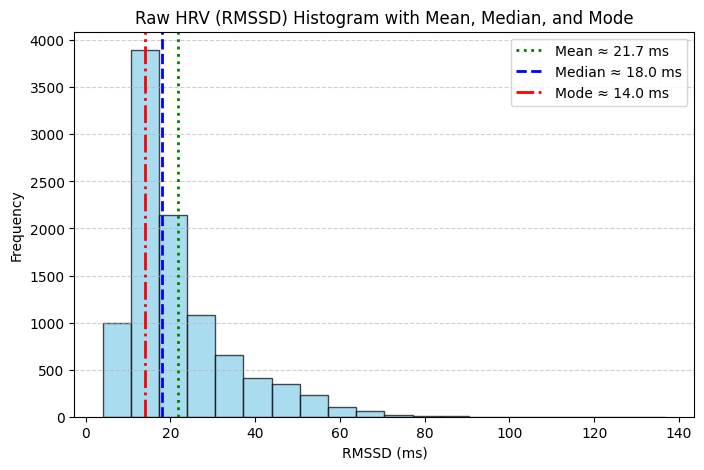

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast

# -----------------------------
# Assuming df_combined already exists and has your HRV column
hrv_col = "hrv"

# Parse HRV string-lists into real Python lists
df_combined["_hrv_parsed"] = df_combined[hrv_col].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else []
)

# Flatten all HRV values into one list
all_hrv_values = [val for sublist in df_combined["_hrv_parsed"] for val in sublist]

# -----------------------------
# 1. Compute mean, median, mode
mean_raw   = np.mean(all_hrv_values)
median_raw = np.median(all_hrv_values)

counts, bin_edges = np.histogram(all_hrv_values, bins=20)
mode_bin_index = np.argmax(counts)
mode_raw = (bin_edges[mode_bin_index] + bin_edges[mode_bin_index+1]) / 2

print(f"Mean HRV   ≈ {mean_raw:.2f} ms")
print(f"Median HRV ≈ {median_raw:.2f} ms")
print(f"Mode HRV   ≈ {mode_raw:.2f} ms")

# -----------------------------
# 2. Plot histogram with lines
plt.figure(figsize=(8, 5))
plt.hist(all_hrv_values, bins=20, edgecolor="black", alpha=0.7, color="skyblue")

# Add vertical lines for mean, median, mode
plt.axvline(mean_raw, color="green", linestyle=":", linewidth=2,
            label=f"Mean ≈ {mean_raw:.1f} ms")
plt.axvline(median_raw, color="blue", linestyle="--", linewidth=2,
            label=f"Median ≈ {median_raw:.1f} ms")
plt.axvline(mode_raw, color="red", linestyle="-.", linewidth=2,
            label=f"Mode ≈ {mode_raw:.1f} ms")

plt.title("Raw HRV (RMSSD) Histogram with Mean, Median, and Mode")
plt.xlabel("RMSSD (ms)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


<Figure size 1000x600 with 0 Axes>

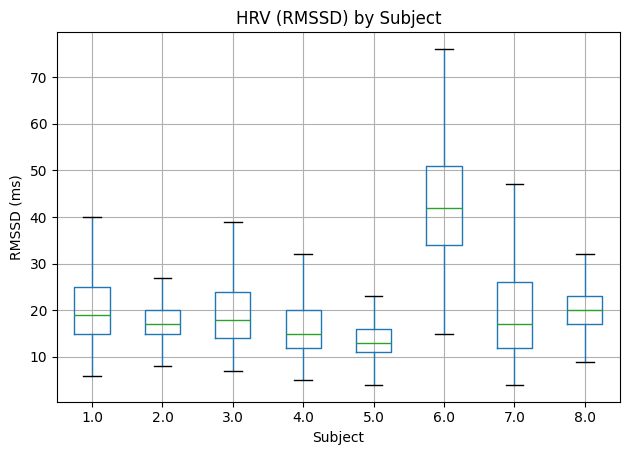

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import ast



# Adjust this to the actual column names in your file
subject_col = "subject_no"    # subject identifier
hrv_col = "hrv"          # the column with HRV lists, like "[35, 42, 28,...]"

# Convert the list strings into real Python lists
df_combined["_hrv_parsed"] = df_combined[hrv_col].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

# Flatten into long form: one row per subject per HRV value
rows = []
for _, row in df_combined.iterrows():
    for v in row["_hrv_parsed"]:
        rows.append({"subject_no": row[subject_col], "hrv": float(v)})
long_df = pd.DataFrame(rows)

# Make the boxplot
plt.figure(figsize=(10,6))
long_df.boxplot(column="hrv", by="subject_no", showfliers=False)
plt.title("HRV (RMSSD) by Subject")
plt.suptitle("")
plt.xlabel("Subject")
plt.ylabel("RMSSD (ms)")
plt.tight_layout()
plt.show()


           day  lowest_heart_rate   avg_brs  subject_no  total_sleep_duration  \
0   2025-05-16               64.0  3.333333         1.0               25200.0   
1   2025-05-17               68.0  3.333333         1.0               27630.0   
2   2025-05-20               68.0  3.333333         1.0               22410.0   
3   2025-05-21               63.0  3.333333         1.0               28950.0   
4   2025-05-22               60.0  3.333333         1.0               23790.0   
..         ...                ...       ...         ...                   ...   
110 2025-08-10               57.0  3.833333         8.0               32490.0   
111 2025-08-12               54.0  3.833333         8.0               22980.0   
112 2025-08-12               54.0  3.833333         8.0               22980.0   
113 2025-08-12               54.0  3.833333         8.0               22980.0   
114 2025-08-15               55.0  3.833333         8.0               21060.0   

     time_in_bed  restless_

<Figure size 1000x600 with 0 Axes>

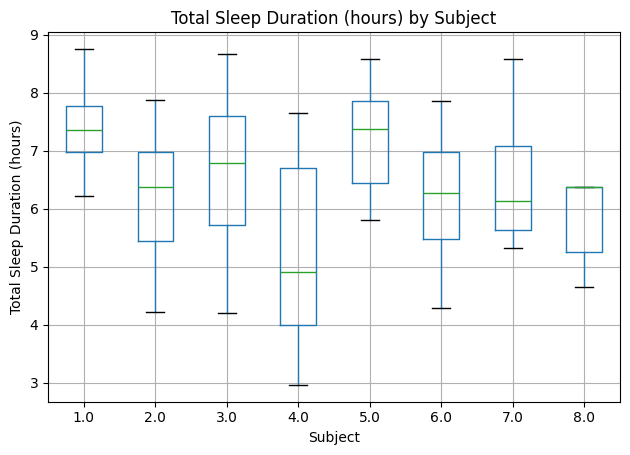

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



# Adjust this to your actual column names
subject_col = "subject_no"        # subject ID
sleep_col   = "total_sleep_duration" # total sleep duration in hours

# Convert seconds to hours
df_combined["total_sleep_hours"] = df_combined[sleep_col] / 3600

print(df_combined)


# Boxplot of total sleep duration per subject
plt.figure(figsize=(10,6))
df_combined.boxplot(column="total_sleep_hours", by=subject_col, showfliers=False)
plt.title("Total Sleep Duration (hours) by Subject")
plt.suptitle("")
plt.xlabel("Subject")
plt.ylabel("Total Sleep Duration (hours)")
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

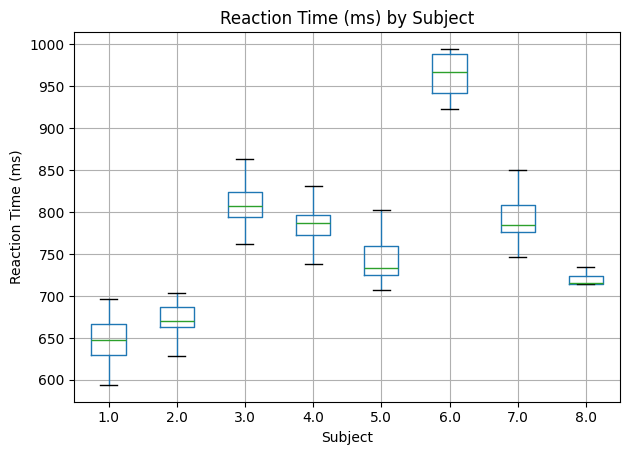

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



# Adjust column names as per your file
subject_col = "subject_no"         # subject ID
rt_col      = "Avg RT Correct Go (ms)"   # column storing reaction times (in ms)

# Boxplot of reaction times per subject
plt.figure(figsize=(10,6))
df_combined.boxplot(column=rt_col, by=subject_col, showfliers=False)
plt.title("Reaction Time (ms) by Subject")
plt.suptitle("")
plt.xlabel("Subject")
plt.ylabel("Reaction Time (ms)")
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

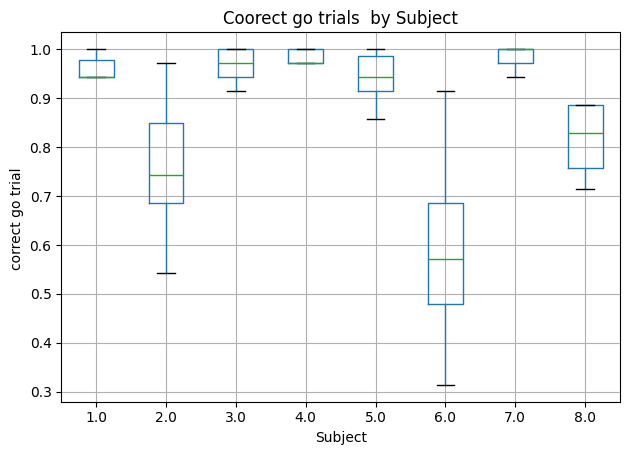

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



# Adjust column names as per your file
subject_col = "subject_no"         # subject ID
go_col      = "Correct Go Trials"   # column storing reaction times (in ms)

# Boxplot of reaction times per subject
plt.figure(figsize=(10,6))
df_combined.boxplot(column=go_col, by=subject_col, showfliers=False)
plt.title("Coorect go trials  by Subject")
plt.suptitle("")
plt.xlabel("Subject")
plt.ylabel("correct go trial ")
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

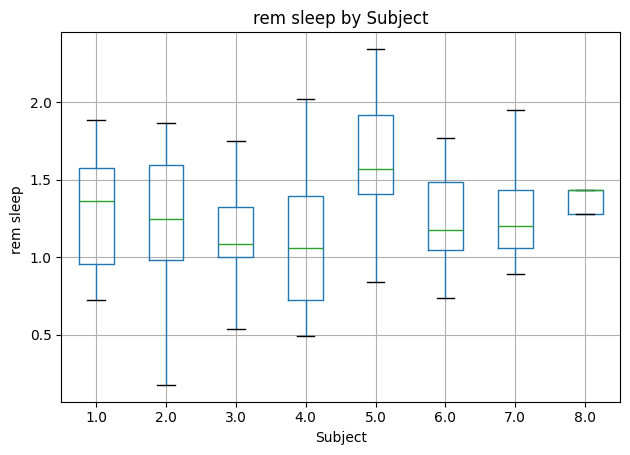

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



# Adjust column names as per your file
subject_col = "subject_no"         # subject ID
rem  = "rem_sleep_duration"   # column storing reaction times (in ms)

df_combined["rem_hours"] = df_combined[rem] / 3600

# Boxplot of reaction times per subject
plt.figure(figsize=(10,6))
df_combined.boxplot(column="rem_hours", by=subject_col, showfliers=False)
plt.title("rem sleep by Subject")
plt.suptitle("")
plt.xlabel("Subject")
plt.ylabel("rem sleep ")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



# Adjust column names if needed
subject_col = "subject_no"
rem_col     = "rem_sleep_duration"   # in seconds
deep_col    = "deep_sleep_duration"  # in seconds

# Convert seconds → hours
df_combined["rem_h"]  = pd.to_numeric(df_combined[rem_col], errors="coerce") / 3600
df_combined["deep_h"] = pd.to_numeric(df_combined[deep_col], errors="coerce") / 3600

# Compute restorative sleep = REM + Deep
df_combined["restorative_h"] = df_combined["rem_h"] + df_combined["deep_h"]

# Drop missing
df_clean = df_combined.dropna(subset=[subject_col, "restorative_h"])

# Boxplot
plt.figure(figsize=(10,6))
df_clean.boxplot(column="restorative_h", by=subject_col, showfliers=False)
plt.title("Restorative Sleep (REM + Deep, hours) by Subject")
plt.suptitle("")
plt.xlabel("Subject")
plt.ylabel("Restorative Sleep (hours)")
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

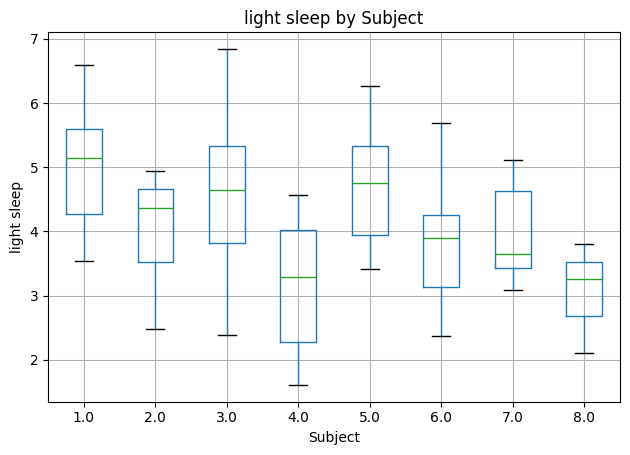

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



# Adjust column names as per your file
subject_col = "subject_no"         # subject ID
light  = "light_sleep_duration"   # column storing reaction times (in ms)

df_combined["light_hours"] = df_combined[light] / 3600

# Boxplot of reaction times per subject
plt.figure(figsize=(10,6))
df_combined.boxplot(column="light_hours", by=subject_col, showfliers=False)
plt.title("light sleep by Subject")
plt.suptitle("")
plt.xlabel("Subject")
plt.ylabel("light sleep")
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

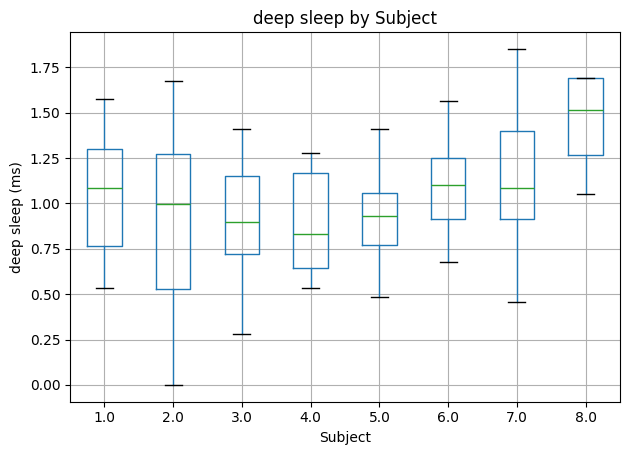

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



# Adjust column names as per your file
subject_col = "subject_no"         # subject ID
deep  = "deep_sleep_duration"   # column storing reaction times (in ms)

df_combined["deep_hours"] = df_combined[deep] / 3600

# Boxplot of reaction times per subject
plt.figure(figsize=(10,6))
df_combined.boxplot(column="deep_hours", by=subject_col, showfliers=False)
plt.title("deep sleep by Subject")
plt.suptitle("")
plt.xlabel("Subject")
plt.ylabel("deep sleep ")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



# Adjust column names as per your file
subject_col = "subject_no"         # subject ID
high_activity = "high_activity_time"  # column storing reaction times (in ms)



# Boxplot of reaction times per subject
plt.figure(figsize=(10,6))
df_combined.boxplot(column=high_activity, by=subject_col, showfliers=False)
plt.title("high_activity by Subject")
plt.suptitle("")
plt.xlabel("Subject")
plt.ylabel("high activity time ")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



# Adjust column names as per your file
subject_col = "subject_no"         # subject ID
equivalent_walking = "equivalent_walking_distance"  # column storing reaction times (in ms)



# Boxplot of reaction times per subject
plt.figure(figsize=(10,6))
df_combined.boxplot(column= equivalent_walking, by=subject_col, showfliers=False)
plt.title("walkng _distance by Subject")
plt.suptitle("")
plt.xlabel("Subject")
plt.ylabel(" walking distance ")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



# Adjust column names as per your file
subject_col = "subject_no"         # subject ID
efficiency = "efficiency"  # column storing reaction times (in ms)



# Boxplot of reaction times per subject
plt.figure(figsize=(10,6))
df_combined.boxplot(column= efficiency, by=subject_col, showfliers=False)
plt.title("efficiency by Subject")
plt.suptitle("")
plt.xlabel("Subject")
plt.ylabel(" efficiency ")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



# Adjust column names as per your file
subject_col = "subject_no"         # subject ID
restless = "restless_periods"  # column storing reaction times (in ms)



# Boxplot of reaction times per subject
plt.figure(figsize=(10,6))
df_combined.boxplot(column= restless, by=subject_col, showfliers=False)
plt.title("restless by Subject")
plt.suptitle("")
plt.xlabel("Subject")
plt.ylabel(" restless ")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



# Adjust column names as per your file
subject_col = "subject_no"         # subject ID
steps = "steps"  # column storing reaction times (in ms)



# Boxplot of reaction times per subject
plt.figure(figsize=(10,6))
df_combined.boxplot(column= steps, by=subject_col, showfliers=False)
plt.title("steps by Subject")
plt.suptitle("")
plt.xlabel("Subject")
plt.ylabel(" steps")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from scipy.stats import pearsonr

# Define your features and targets
features = ['lowest_heart_rate','total_sleep_duration','time_in_bed','restless_periods', 'rem_sleep_duration' , 'light_sleep_duration','deep_sleep_duration' , 'efficiency' , 'average_heart_rate','average_breath','average_hrv','avg_brs','active_calories','average_met_minutes','equivalent_walking_distance','high_activity_met_minutes','high_activity_time'
,'steps',
'total_calories']

targets = [ 'Avg RT Correct Go (ms)']

# Drop rows with NaNs in any of the needed columns
#df_data = df_cleaned.dropna(subset=features + targets)

#df_data

# Store correlation results
results = []

for feat in features:
    for targ in targets:
        r, p = pearsonr(df_combined[feat], df_combined[targ])
        results.append({
            'Sleep Feature': feat,
            'Behavioral Target': targ,
            'Pearson r': round(r, 3),
            'p-value': round(p, 5),
            'Significance': '✅' if p < 0.05 else '❌'
        })

# Convert to DataFrame
correlation_results = pd.DataFrame(results)

correlation_results

In [ ]:
df_combined

In [ ]:
import pandas as pd
from scipy.stats import pearsonr

# Define your features and targets
features = ['lowest_heart_rate_rollavg',
       'avg_brs_rollavg', 'total_sleep_duration_rollavg',
       'time_in_bed_rollavg', 'restless_periods_rollavg',
       'rem_sleep_duration_rollavg', 'light_sleep_duration_rollavg',
       'deep_sleep_duration_rollavg', 'efficiency_rollavg',
        'average_heart_rate_rollavg',
       'average_breath_rollavg','average_hrv_rollavg']

targets = [ 'Avg RT Correct Go (ms)']

# Drop rows with NaNs in any of the needed columns
#df_data = df_cleaned.dropna(subset=features + targets)

#df_data

# Store correlation results
results = []

for feat in features:
    for targ in targets:
        r, p = pearsonr(df_combined[feat], df_combined[targ])
        results.append({
            'Sleep Feature': feat,
            'Behavioral Target': targ,
            'Pearson r': round(r, 3),
            'p-value': round(p, 5),
            'Significance': '✅' if p < 0.05 else '❌'
        })

# Convert to DataFrame
correlation_results_1 = pd.DataFrame(results)
correlation_results_1

In [ ]:
import pandas as pd
from scipy.stats import pearsonr

# Define your features and targets
features = ['lowest_heart_rate','avg_brs','total_sleep_duration','time_in_bed','restless_periods', 'rem_sleep_duration' , 'light_sleep_duration','deep_sleep_duration' , 'efficiency',  'average_hrv' , 'average_heart_rate','average_breath']

targets = [ 'lowest_heart_rate','avg_brs','total_sleep_duration','time_in_bed','restless_periods', 'rem_sleep_duration' , 'light_sleep_duration','deep_sleep_duration' , 'efficiency',  'average_hrv' , 'average_heart_rate','average_breath']


# Drop rows with NaNs in any of the needed columns
#df_data = df_cleaned.dropna(subset=features + targets)

#df_data

# Store correlation results
results = []

for feat in features:
    for targ in targets:
        r, p = pearsonr(df_combined[feat], df_combined[targ])
        results.append({
            'Sleep Feature': feat,
            'Behavioral Target': targ,
            'Pearson r': round(r, 3),
            'p-value': round(p, 5),
            'Significance': '✅' if p < 0.05 else '❌'
        })

# Convert to DataFrame
correlation_results = pd.DataFrame(results)

correlation_results

In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Define your features
features = [
   'lowest_heart_rate_rollavg',
       'avg_brs_rollavg', 'total_sleep_duration_rollavg',
       'time_in_bed_rollavg', 'restless_periods_rollavg',
       'rem_sleep_duration_rollavg', 'light_sleep_duration_rollavg',
       'deep_sleep_duration_rollavg', 'efficiency_rollavg', 'average_heart_rate_rollavg',
       'average_breath_rollavg','average_hrv_rollavg'
]

# Drop rows with missing values
df_vif = df_combined[features].dropna().copy()

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_vif)

# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = df_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]

# Display the VIF values
print("\n📊 Variance Inflation Factors (VIF):")
print(vif_data.sort_values("VIF", ascending=False))


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Define features and target
features = [
    'lowest_heart_rate', 'total_sleep_duration', 'time_in_bed',
    'restless_periods', 'rem_sleep_duration', 'light_sleep_duration',
    'deep_sleep_duration', 'efficiency', 'average_hrv',
    'average_heart_rate', 'average_breath',
]
target = 'Avg RT Correct Go (ms)'

# Drop missing values
df_model = df_combined.dropna(subset=features + [target, 'subject_no']).copy()

# -----------------------------
# Standardize Features and Target
# -----------------------------
scaler_X = MinMaxScaler()
df_model[features] = scaler_X.fit_transform(df_model[features])

scaler_y = MinMaxScaler()
df_model[target] = scaler_y.fit_transform(df_model[[target]])

# -----------------------------
# Multiple Linear Regression Model Summary
# -----------------------------
X = sm.add_constant(df_model[features])
y = df_model[target]
model = sm.OLS(y, X).fit()
print(model.summary())

# -----------------------------
# R² for each feature individually
# -----------------------------
r2_scores = []
for feature in features:
    X_feat = sm.add_constant(df_model[[feature]])
    y_feat = df_model[target]
    model_feat = sm.OLS(y_feat, X_feat).fit()
    y_pred_feat = model_feat.predict(X_feat)
    r2 = r2_score(y_feat, y_pred_feat)
    r2_scores.append({'Feature': feature, 'R²': round(r2, 4)})

r2_df = pd.DataFrame(r2_scores)
print("\n📊 R² values for individual features:\n", r2_df)




In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast

# ----------------------------
# Step 1: Convert HRV string to list
# ----------------------------

df_combined['hrv'] = df_combined['hrv'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith('[') else x
)

# ----------------------------
# Step 2: Flatten HRV list and include subject info
# ----------------------------

hrv_values = []
reaction_times = []
subject_ids = []

for _, row in df_combined.iterrows():
    hrv_list = row['hrv']
    rt = row['Avg RT Correct Go (ms)']
    subject = row['subject_no'] if 'subject_no' in row else 'Unknown'

    if isinstance(hrv_list, list) and pd.notna(rt):
        for hrv in hrv_list:
            if isinstance(hrv, (int, float)) and pd.notna(hrv):
                hrv_values.append(hrv)
                reaction_times.append(rt)
                subject_ids.append(subject)

# ----------------------------
# Step 3: Create long-format DataFrame
# ----------------------------

df_plot = pd.DataFrame({
    'HRV': hrv_values,
    'ReactionTime': reaction_times,
    'Subject': subject_ids
})

# ----------------------------
# Step 4: Plot separate regression plots per subject
# ----------------------------

g = sns.FacetGrid(df_plot, col='Subject', col_wrap=4, height=4, sharex=False, sharey=False)
g.map_dataframe(sns.regplot, x='HRV', y='ReactionTime', scatter_kws={'alpha': 0.5})
g.set_axis_labels("HRV", "Avg RT Correct Go (ms)")
g.set_titles(col_template="Subject: {col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('HRV vs Reaction Time (One Plot per Participant)', fontsize=16)
plt.show()


In [ ]:
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import ast

# ----------------------------
# Step 1: Convert stringified HRV lists into actual lists
# ----------------------------
df_combined['hrv'] = df_combined['hrv'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith('[') else x
)

# ----------------------------
# Step 2: Flatten all HRV–ReactionTime pairs into one DataFrame
# ----------------------------

hrv_values = []
reaction_times = []

for _, row in df_combined.iterrows():
    hrv_list = row['hrv']
    rt = row['Avg RT Correct Go (ms)']

    if isinstance(hrv_list, list) and pd.notna(rt):
        for hrv in hrv_list:
            if isinstance(hrv, (int, float)) and pd.notna(hrv):
                hrv_values.append(hrv)
                reaction_times.append(rt)

df_plot = pd.DataFrame({
    'HRV': hrv_values,
    'ReactionTime': reaction_times
})

# ----------------------------
# Step 3: Calculate Pearson r and plot
# ----------------------------

r, p = pearsonr(df_plot['HRV'], df_plot['ReactionTime'])

plt.figure(figsize=(8, 5))
sns.regplot(data=df_plot, x='HRV', y='ReactionTime', scatter_kws={'alpha': 0.5})
plt.title(f'HRV vs Reaction Time\nPearson r = {r:.3f}, p = {p:.5f}')
plt.xlabel('HRV (from list)')
plt.ylabel('Avg RT Correct Go (ms)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import ast

# ----------------------------
# Step 1: Parse HRV string to list
# ----------------------------
df_combined['hrv'] = df_combined['hrv'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith('[') else x
)

# ----------------------------
# Step 2: Apply rolling average to each HRV list (window=2)
# ----------------------------
def rolling_avg_list(hrv_list, window=5):
    if isinstance(hrv_list, list) and len(hrv_list) >= window:
        return pd.Series(hrv_list).rolling(window=window, min_periods=1).mean().tolist()
    return hrv_list  # return original list if too short

df_combined['hrv_rolling'] = df_combined['hrv'].apply(lambda x: rolling_avg_list(x, window=2))

# ----------------------------
# Step 3: Compute summary stats on rolling HRV list
# ----------------------------
df_combined['hrv_mean'] = df_combined['hrv_rolling'].apply(
    lambda x: np.mean(x) if isinstance(x, list) and len(x) > 0 else np.nan)

df_combined['hrv_std'] = df_combined['hrv_rolling'].apply(
    lambda x: np.std(x) if isinstance(x, list) and len(x) > 0 else np.nan)

df_combined['hrv_max'] = df_combined['hrv_rolling'].apply(
    lambda x: np.max(x) if isinstance(x, list) and len(x) > 0 else np.nan)

df_combined['hrv_min'] = df_combined['hrv_rolling'].apply(
    lambda x: np.min(x) if isinstance(x, list) and len(x) > 0 else np.nan)

# ----------------------------
# Step 4: Multiple regression
# ----------------------------
predictors = ['hrv_mean', 'hrv_std', 'hrv_max', 'hrv_min']
target = 'Avg RT Correct Go (ms)'
subject_column = 'subject_no'

# Drop missing values
df_mode_1 = df_combined[predictors + [target, subject_column]].dropna()

# Prepare X and y for regression
X = sm.add_constant(df_mode_1[predictors])
y = df_mode_1[target]

# Run regression
if len(df_mode_1) >= 2:
    model = sm.OLS(y, X).fit()
    print(model.summary())
else:
    print("⚠️ Not enough data to run regression.")

# ----------------------------
# Step 5: Regression lines per subject (combined plot)
# ----------------------------
plt.figure(figsize=(8, 6))

for subject, group in df_mode_1.groupby(subject_column):
    if len(group) >= 2:
        sns.regplot(
            data=group,
            x='hrv_mean',
            y=target,
            scatter=True,
            label=f'{subject}',
            ci=None,
            scatter_kws={'alpha': 0.5, 's': 30},
            line_kws={'linewidth': 1}
        )

plt.title("HRV Mean (Rolling Avg) vs Reaction Time per Subject")
plt.xlabel("HRV Mean (Rolling Avg)")
plt.ylabel(target)
plt.legend(title='Participant', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("hrv_vs_rt_by_subject_1.svg", format='svg')
plt.show()

# ----------------------------
# Step 6: Subplots per subject
# ----------------------------
sns.lmplot(
    data=df_mode_1,
    x='hrv_mean',
    y=target,
    col=subject_column,
    col_wrap=4,
    height=4,
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)
plt.subplots_adjust(top=0.9)
plt.suptitle("HRV Mean (Rolling Avg) vs Reaction Time by Subject")
plt.savefig("hrv_vs_rt_by_subject.svg", format='svg')  # Save as SVG
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Define features and target
features_rolling= [
    'lowest_heart_rate_rollavg',
       'avg_brs_rollavg', 'total_sleep_duration_rollavg',
       'time_in_bed_rollavg', 'restless_periods_rollavg',
       'rem_sleep_duration_rollavg', 'light_sleep_duration_rollavg',
       'deep_sleep_duration_rollavg', 'efficiency_rollavg', 'average_heart_rate_rollavg',
       'average_breath_rollavg','average_hrv_rollavg'
]
target_rolling = 'Avg RT Correct Go (ms)'

# Drop missing values based on rolling features
df_model_rolling = df_combined.dropna(subset=features_rolling + [target_rolling, 'subject_no']).copy()

# -----------------------------
# Standardize Features and Target
# -----------------------------
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(df_model_rolling[features_rolling])
X_scaled_df = pd.DataFrame(X_scaled, columns=features_rolling, index=df_model_rolling.index)


scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(df_model_rolling[[target_rolling]]).ravel()
y_scaled_series = pd.Series(y_scaled, index=df_model_rolling.index, name=target_rolling)


# -----------------------------
# Multiple Linear Regression Model Summary
# -----------------------------
X = sm.add_constant(X_scaled_df) # Use scaled features
y = y_scaled_series # Use scaled target
model = sm.OLS(y, X).fit()
print(model.summary())

# -----------------------------
# R² for each feature individually
# -----------------------------
r2_scores = []
for feature in features_rolling: # Use rolling features
    X_feat = sm.add_constant(X_scaled_df[[feature]]) # Use scaled rolling features
    y_feat = y_scaled_series # Use scaled target
    model_feat = sm.OLS(y_feat, X_feat).fit()
    y_pred_feat = model_feat.predict(X_feat)
    r2 = r2_score(y_feat, y_pred_feat)
    r2_scores.append({'Feature': feature, 'R²': round(r2, 4)})

r2_df = pd.DataFrame(r2_scores)
print("\n📊 R² values for individual features:\n", r2_df)

# -----------------------------
# Subject-wise Regression Plots
# -----------------------------
# Use df_model_rolling for subject data and scaled data for plotting
for feature in features_rolling:
    plt.figure(figsize=(10, 6))
    for subject in df_model_rolling['subject_no'].unique():
        # Get the indices for the current subject in the main df_model_rolling
        subject_indices = df_model_rolling[df_model_rolling['subject_no'] == subject].index

        if len(subject_indices) < 2:
            continue

        # Select scaled data for the current subject using the indices
        X_sub_scaled = X_scaled_df.loc[subject_indices, [feature]]
        y_sub_scaled = y_scaled_series.loc[subject_indices]

        # Fit linear regression model on scaled data
        model_sub = sm.OLS(y_sub_scaled, sm.add_constant(X_sub_scaled)).fit()
        y_pred_sub_scaled = model_sub.predict(sm.add_constant(X_sub_scaled))

        # Compute R² score on scaled data
        r2 = r2_score(y_sub_scaled, y_pred_sub_scaled)


        # Plot scaled data and regression line
        sns.regplot(
            x=X_sub_scaled[feature],
            y=y_sub_scaled,
            label=f'Subject {subject} (R²={r2:.2f})',
            ci=None,
            scatter=True,
             line_kws={'linewidth': 1} # Make lines thinner

        )
    plt.title(f'Regression per Subject (Rolling Features): {feature}')
    plt.xlabel(feature + ' (scaled)')
    plt.ylabel(target_rolling + ' (scaled)')
    plt.legend(title="Subject", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
pip install pygam

In [ ]:
from pygam import LinearGAM, s
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Define your features and target
features = [
    'lowest_heart_rate', 'avg_brs', 'total_sleep_duration', 'time_in_bed',
    'restless_periods', 'rem_sleep_duration', 'light_sleep_duration',
    'deep_sleep_duration', 'efficiency', 'average_hrv',
    'average_heart_rate', 'average_breath'
]
target = 'Avg RT Correct Go (ms)'

# Drop missing values
df_gam_1 = df_combined.dropna(subset=features + [target]).copy()

# Normalize predictors
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(df_gam_1[features])

# Normalize target (optional but common with GAM)
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(df_gam_1[[target]]).ravel()

# Define the GAM model with smoothing terms
gam = LinearGAM(s(0, n_splines=4, lam=1) + s(1, n_splines=4, lam=1) + s(2, n_splines=4, lam=1) +
    s(3, n_splines=4, lam=1) + s(4, n_splines=4, lam=1) + s(5, n_splines=4, lam=1) +
    s(6, n_splines=4, lam=1) + s(7, n_splines=4, lam=1) + s(8, n_splines=4, lam=1) +
    s(9, n_splines=4, lam=1) + s(10, n_splines=4, lam=1) + s(11, n_splines=4, lam=1)).fit(X_scaled, y_scaled)

# Print significance (p-values) of each term
print("✅ Significance of smooth terms (p-values):\n")
for i, term in enumerate(features):
    pval = gam.statistics_['p_values'][i]
    print(f"{term:<25} p = {pval:.5f} {'✅' if pval < 0.05 else '❌'}")


In [ ]:
from pygam import LinearGAM, s
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Define your features and target
features = [
    'lowest_heart_rate_rollavg',
       'avg_brs_rollavg', 'total_sleep_duration_rollavg',
       'time_in_bed_rollavg', 'restless_periods_rollavg',
       'rem_sleep_duration_rollavg', 'light_sleep_duration_rollavg',
       'deep_sleep_duration_rollavg', 'efficiency_rollavg', 'average_heart_rate_rollavg',
       'average_breath_rollavg','average_hrv_rollavg'
]
target = 'Avg RT Correct Go (ms)'

# Drop missing values
df_gam_P_rolling = df_combined.dropna(subset=features + [target]).copy()

# Normalize predictors
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(df_gam_P_rolling[features])

# Normalize target (optional but common with GAM)
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(df_gam_P_rolling[[target]]).ravel()

# Define the GAM model with smoothing terms
gam_roling_1 = LinearGAM(s(0, n_splines=4, lam=1) + s(1, n_splines=4, lam=1) + s(2, n_splines=4, lam=1) +
    s(3, n_splines=4, lam=1) + s(4, n_splines=4, lam=1) + s(5, n_splines=4, lam=1) +
    s(6, n_splines=4, lam=1) + s(7, n_splines=4, lam=1) + s(8, n_splines=4, lam=1) +
    s(9, n_splines=4, lam=1) + s(10, n_splines=4, lam=1)).fit(X_scaled, y_scaled)

# Print significance (p-values) of each term
print("✅ Significance of smooth terms (p-values):\n")
for i, term in enumerate(features):
    pval = gam_roling_1.statistics_['p_values'][i]
    print(f"{term:<25} p = {pval:.5f} {'✅' if pval < 0.01 else '❌'}")



# sanity check: how many terms does GAM think it has?


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load the dataset
df = pd.read_csv("combined_output.csv")

# Define features and target
features = [
    'lowest_heart_rate', 'avg_brs', 'total_sleep_duration', 'time_in_bed',
    'restless_periods', 'rem_sleep_duration', 'light_sleep_duration',
    'deep_sleep_duration', 'efficiency', 'average_hrv',
    'average_heart_rate', 'average_breath'
]
target = 'Avg RT Correct Go (ms)'

# Drop rows with missing values
df_model = df.dropna(subset=features + [target, 'subject_no'])

# Loop through each feature
for feature in features:
    plt.figure(figsize=(10, 6))

    for subject in df_model['subject_no'].unique():
        df_sub = df_model[df_model['subject_no'] == subject]
        X = df_sub[[feature]].values
        y = df_sub[target].values

        # Fit linear regression model
        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)

        # Compute R² score
        r2 = r2_score(y, y_pred)

        # Plot data and regression line
        plt.scatter(X, y, alpha=0.6, label=f'Subject {subject} (R²={r2:.2f})')
        plt.plot(X, y_pred, linewidth=2)

    plt.xlabel(feature)
    plt.ylabel(target)
    plt.title(f'Linear Regression: {feature} vs {target}')
    plt.legend()
    plt.tight_layout()
    plt.show()


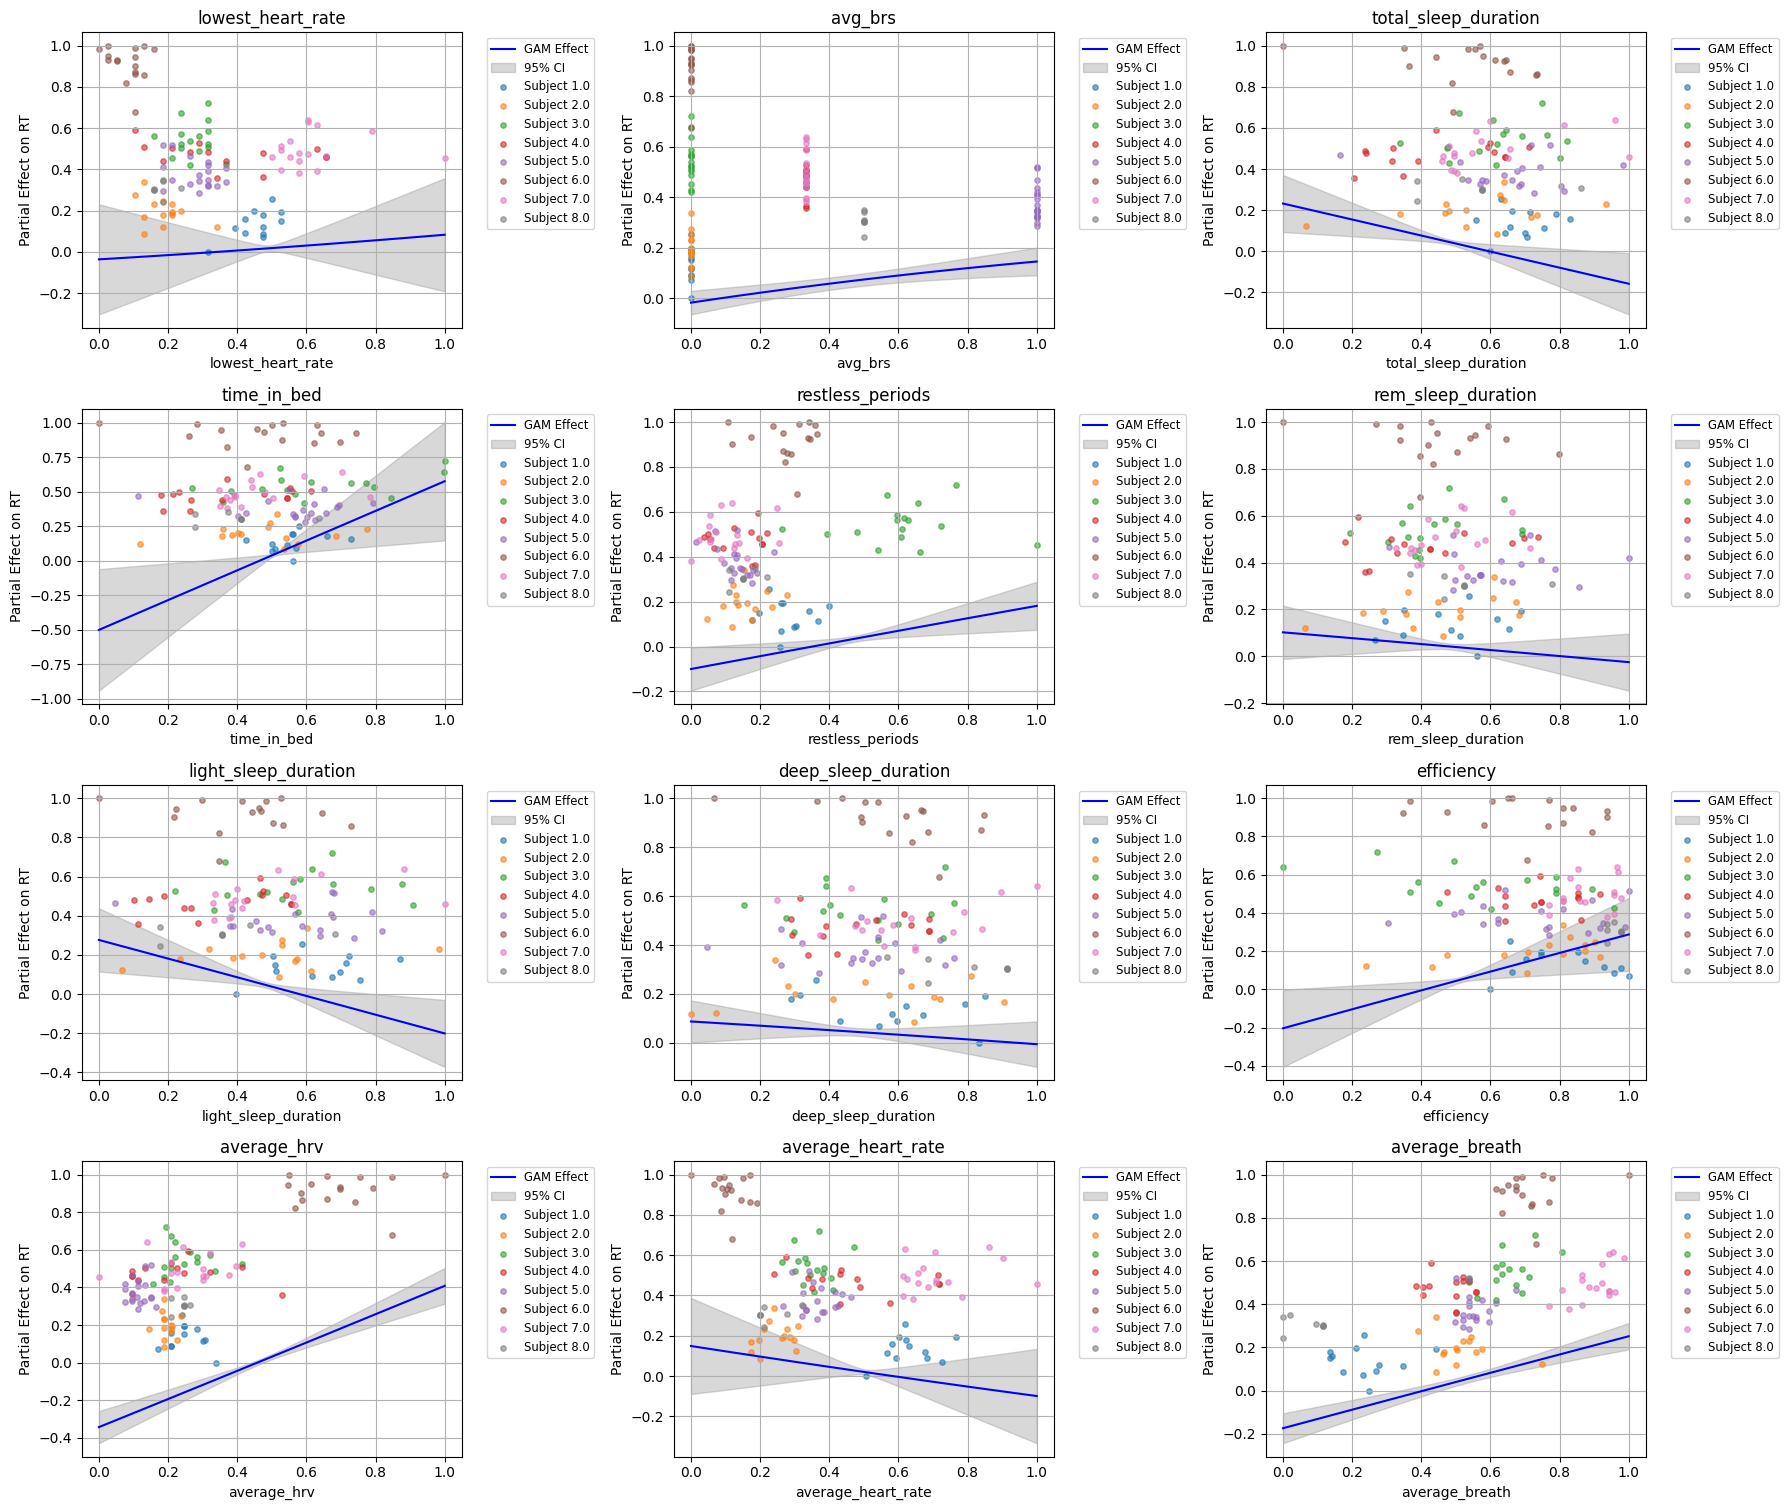

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pygam import LinearGAM, s
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score
import math

# Define your features and target
features = [
    'lowest_heart_rate', 'avg_brs', 'total_sleep_duration', 'time_in_bed',
    'restless_periods', 'rem_sleep_duration', 'light_sleep_duration',
    'deep_sleep_duration', 'efficiency', 'average_hrv',
    'average_heart_rate', 'average_breath'
]
target = 'Avg RT Correct Go (ms)'

# Drop missing values
df_gam = df_combined.dropna(subset=features + [target, 'subject_no']).copy()

# Standardize predictors and target
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(df_gam[features])

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(df_gam[[target]]).ravel()

# Save into a DataFrame for plotting later
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df['subject_no'] = df_gam['subject_no'].values
X_scaled_df['y_scaled'] = y_scaled

# Fit full GAM model
gam = LinearGAM(
    s(0, n_splines=4, lam=1) + s(1, n_splines=4, lam=1) + s(2, n_splines=4, lam=1) +
    s(3, n_splines=4, lam=1) + s(4, n_splines=4, lam=1) + s(5, n_splines=4, lam=1) +
    s(6, n_splines=4, lam=1) + s(7, n_splines=4, lam=1) + s(8, n_splines=4, lam=1) +
    s(9, n_splines=4, lam=1) + s(10, n_splines=4, lam=1) + s(11, n_splines=4, lam=1)
).fit(X_scaled, y_scaled)

# Compute R² and pseudo-R²
y_pred_scaled = gam.predict(X_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_true = df_gam[target].values

r2 = r2_score(y_true, y_pred)
pseudo_r2 = gam.statistics_['pseudo_r2']['explained_deviance']

print(f"R² (original units): {r2:.3f}")
print(f"Pseudo-R² (explained deviance): {pseudo_r2:.3f}")

for i, feature in enumerate(features):
    X_feat = X_scaled[:, i].reshape(-1, 1)
    gam_uni = LinearGAM(s(0, n_splines=4, lam=1)).fit(X_feat, y_scaled)
    y_pred_uni = gam_uni.predict(X_feat)
    y_pred_orig = scaler_y.inverse_transform(y_pred_uni.reshape(-1, 1)).ravel()
    r2_individual = r2_score(y_true, y_pred_orig)

    print(f"{feature:<25}: R² = {r2_individual:>7.4f}")

# Plot partial dependence with subject data points
num_features = len(features)
cols = 3
rows = math.ceil(num_features / cols)
plt.figure(figsize=(6 * cols, 4 * rows))

for i, feature in enumerate(features):
    plt.subplot(rows, cols, i + 1)
    try:
        XX = gam.generate_X_grid(term=i)
        pdep = gam.partial_dependence(term=i, X=XX)
        confi = gam.partial_dependence(term=i, X=XX, width=0.95)[1]

        # Unpack confidence interval
        if isinstance(confi, tuple) and len(confi) == 2:
            lower, upper = confi
        else:
            lower, upper = confi.T

        # Plot GAM curve and CI
        plt.plot(XX[:, i], pdep, color='blue', label='GAM Effect')
        plt.fill_between(XX[:, i], lower, upper, alpha=0.3, color='gray', label='95% CI')

        # Plot subject-wise data
        for subj in X_scaled_df['subject_no'].unique():
            subj_df = X_scaled_df[X_scaled_df['subject_no'] == subj]
            plt.scatter(subj_df[feature], subj_df['y_scaled'], label=f'Subject {subj}', alpha=0.6, s=15)

        plt.title(feature)
        plt.xlabel(feature)
        plt.ylabel("Partial Effect on RT")
        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    except Exception as e:
        plt.title(f"{feature} (Error)")
        print(f"⚠️ Error plotting {feature}: {e}")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("subject_gam_model_1.svg", format='svg')
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pygam import LinearGAM, s
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import math

# Define your features and target
features = [
    'lowest_heart_rate_rollavg',
       'avg_brs_rollavg', 'total_sleep_duration_rollavg',
       'time_in_bed_rollavg', 'restless_periods_rollavg',
       'rem_sleep_duration_rollavg', 'light_sleep_duration_rollavg',
       'deep_sleep_duration_rollavg', 'efficiency_rollavg', 'average_heart_rate_rollavg',
       'average_breath_rollavg','average_hrv_rollavg'
]
target = 'Avg RT Correct Go (ms)'

# Drop missing values
df_gam_rolling = df_combined.dropna(subset=features + [target, 'subject_no']).copy()

# Standardize predictors and target
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(df_gam_rolling[features])

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(df_gam_rolling[[target]]).ravel()

# Save into a DataFrame for plotting later
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df['subject_no'] = df_gam['subject_no'].values
X_scaled_df['y_scaled'] = y_scaled

# Fit full GAM model
gam_rolling = LinearGAM(
   s(0, n_splines=4, lam=1) + s(1, n_splines=4, lam=1) + s(2, n_splines=4, lam=1) +
    s(3, n_splines=4, lam=1) + s(4, n_splines=4, lam=1) + s(5, n_splines=4, lam=1) +
    s(6, n_splines=4, lam=1) + s(7, n_splines=4, lam=1) + s(8, n_splines=4, lam=1) +
    s(9, n_splines=4, lam=1) + s(10, n_splines=4, lam=1)
).fit(X_scaled, y_scaled)

# Print significance (p-values) of each term
print("✅ Significance of smooth terms (p-values):\n")
for i, term in enumerate(features):
    pval = gam_rolling.statistics_['p_values'][i]
    print(f"{term:<25} p = {pval:.5f} {'✅' if pval < 0.05 else '❌'}")


# Compute R² and pseudo-R²
y_pred_scaled = gam_rolling.predict(X_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_true = df_gam_rolling[target].values

r2 = r2_score(y_true, y_pred)
pseudo_r2 = gam_rolling.statistics_['pseudo_r2']['explained_deviance']

print(f"R² (original units): {r2:.3f}")
print(f"Pseudo-R² (explained deviance): {pseudo_r2:.3f}")

for i, feature in enumerate(features):
    X_feat = X_scaled[:, i].reshape(-1, 1)
    gam_uni = LinearGAM(s(0, n_splines=4, lam=1)).fit(X_feat, y_scaled)
    y_pred_uni = gam_uni.predict(X_feat)
    y_pred_orig = scaler_y.inverse_transform(y_pred_uni.reshape(-1, 1)).ravel()
    r2_individual = r2_score(y_true, y_pred_orig)

    print(f"{feature:<25}: R² = {r2_individual:>7.4f}")

# Plot partial dependence with subject data points
num_features = len(features)
cols = 3
rows = math.ceil(num_features / cols)
plt.figure(figsize=(6 * cols, 4 * rows))

for i, feature in enumerate(features):
    plt.subplot(rows, cols, i + 1)
    try:
        XX = gam.generate_X_grid(term=i)
        pdep = gam.partial_dependence(term=i, X=XX)
        confi = gam.partial_dependence(term=i, X=XX, width=0.95)[1]

        # Unpack confidence interval
        if isinstance(confi, tuple) and len(confi) == 2:
            lower, upper = confi
        else:
            lower, upper = confi.T

        # Plot GAM curve and CI
        plt.plot(XX[:, i], pdep, color='blue', label='GAM Effect')
        plt.fill_between(XX[:, i], lower, upper, alpha=0.3, color='gray', label='95% CI')

        # Plot subject-wise data
        for subj in X_scaled_df['subject_no'].unique():
            subj_df = X_scaled_df[X_scaled_df['subject_no'] == subj]
            plt.scatter(subj_df[feature], subj_df['y_scaled'], label=f'Subject {subj}', alpha=0.6, s=15)

        plt.title(feature)
        plt.xlabel(feature)
        plt.ylabel("Partial Effect on RT")
        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    except Exception as e:
        plt.title(f"{feature} (Error)")
        print(f"⚠️ Error plotting {feature}: {e}")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("subject_gam_model_2.svg", format='svg')
plt.show()


✅ Significance of smooth terms (p-values):

lowest_heart_rate_rollavg p = 0.00000 ✅
avg_brs_rollavg           p = 0.02937 ✅
total_sleep_duration_rollavg p = 0.01762 ✅
time_in_bed_rollavg       p = 0.23645 ❌
restless_periods_rollavg  p = 0.00010 ✅
rem_sleep_duration_rollavg p = 0.27562 ❌
light_sleep_duration_rollavg p = 0.00185 ✅
deep_sleep_duration_rollavg p = 0.10134 ❌
efficiency_rollavg        p = 0.12591 ❌
average_heart_rate_rollavg p = 0.00000 ✅
average_breath_rollavg    p = 0.00000 ✅
average_hrv_rollavg       p = 0.00000 ✅
R² (original units): 0.665
Pseudo-R² (explained deviance): 0.665
lowest_heart_rate_rollavg: R² =  0.1187
avg_brs_rollavg          : R² =  0.0264
total_sleep_duration_rollavg: R² =  0.0616
time_in_bed_rollavg      : R² =  0.0029
restless_periods_rollavg : R² =  0.0581
rem_sleep_duration_rollavg: R² =  0.0416
light_sleep_duration_rollavg: R² =  0.0513
deep_sleep_duration_rollavg: R² =  0.0028
efficiency_rollavg       : R² =  0.0657
average_heart_rate_rollavg: R² =

In [ ]:
import pandas as pd
import statsmodels.api as sm

def stepwise_selection(X, y,
                       initial_list=[],
                       threshold_in=0.05,
                       threshold_out=0.10,
                       verbose=True):
    included = list(initial_list)
    while True:
        changed = False
        # forward step
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded, dtype=float)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included + [new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True
            if verbose:
                print(f'✅ Add  {best_feature:30} with p-value {best_pval:.6f}')
        if not changed:
            break
    return included


In [ ]:
# Assuming df_combined is your DataFrame
features = [
      'lowest_heart_rate_rollavg',
       'avg_brs_rollavg', 'total_sleep_duration_rollavg',
       'time_in_bed_rollavg', 'restless_periods_rollavg',
       'rem_sleep_duration_rollavg', 'light_sleep_duration_rollavg',
       'deep_sleep_duration_rollavg', 'efficiency_rollavg', 'average_heart_rate_rollavg',
       'average_breath_rollavg','average_hrv_rollavg'
]
target = 'Avg RT Correct Go (ms)'

df_model = df_combined.dropna(subset=features + [target])
X = df_model[features]
y = df_model[target]

# Run stepwise regression
selected_features = stepwise_selection(X, y)

# Final model
X_selected = sm.add_constant(X[selected_features])
final_model = sm.OLS(y, X_selected).fit()
print("\n📊 Final Model Summary:")
print(final_model.summary())


In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# --- Load and clean data ---
df = df_combined.copy()

features = [
    'lowest_heart_rate','total_sleep_duration','time_in_bed','restless_periods', 'rem_sleep_duration' , 'light_sleep_duration','deep_sleep_duration' , 'efficiency' , 'average_heart_rate','average_breath','average_hrv','avg_brs'
]
target = 'Avg RT Correct Go (ms)'

X_all = df[features]
y = df[target]

df = df.dropna(subset=features + [target]).copy()



# --- Stepwise forward selection ---
def stepwise_selection(X, y, threshold_in=0.05):
    included = []
    while True:
        changed = False
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded, dtype=float)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(X[included + [new_column]])).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True
        if not changed:
            break
    return included

selected_features = stepwise_selection(X_all, y)
print(f"\n✅ Selected features: {selected_features}")

# --- Final model ---
X_final = sm.add_constant(X_all[selected_features])
final_model = sm.OLS(y, X_final).fit()
print("\n📄 Final Model Summary:")
print(final_model.summary())




In [ ]:
# ----- Ridge regression for Avg RT Correct Go (ms) -----
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1) Columns (adjust names if needed)
features_ridge = [
    'lowest_heart_rate','total_sleep_duration','time_in_bed','restless_periods', 'rem_sleep_duration' , 'light_sleep_duration','deep_sleep_duration' , 'efficiency' , 'average_heart_rate','average_breath','average_hrv','avg_brs'
]
target_rt = "Avg RT Correct Go (ms)"

# 2) Prep data
df_r = df_combined.dropna(subset=features_ridge + [target_rt]).copy()
X = df_r[features_ridge].values
y = df_r[target_rt].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3) Standardize predictors
scalerX = StandardScaler()
X_train_s = scalerX.fit_transform(X_train)
X_test_s  = scalerX.transform(X_test)

# 4) Ridge with CV to pick alpha
alphas = np.logspace(-3, 6, 100)  # wide range
ridge = RidgeCV(alphas=alphas, cv=10, scoring="neg_mean_squared_error")
ridge.fit(X_train_s, y_train)

print(f"Best alpha (λ): {ridge.alpha_:.6g}")

# 5) Evaluate (RMSE via sqrt(MSE) for older sklearn)
def metrics(y_true, y_hat, split):
    r2  = r2_score(y_true, y_hat)
    rmse = np.sqrt(mean_squared_error(y_true, y_hat))
    mae = mean_absolute_error(y_true, y_hat)
    print(f"{split}  R²={r2:.3f}  RMSE={rmse:.3f}  MAE={mae:.3f}")

metrics(y_train, ridge.predict(X_train_s), "Train")
metrics(y_test,  ridge.predict(X_test_s),  "Test")

# 6) Coefficients (standardized scale = effect per +1 SD of feature)
coef_std = pd.Series(ridge.coef_, index=features_ridge)

# 7) Convert coefficients back to original units
X_means = scalerX.mean_
X_stds  = scalerX.scale_
coef_orig_vals = ridge.coef_ / X_stds
intercept_orig = ridge.intercept_ - np.sum((ridge.coef_ * X_means) / X_stds)

coef_table = (
    pd.DataFrame({
        "feature": features_ridge,
        "coef_std": coef_std.values,
        "coef_orig": coef_orig_vals
    })
    .sort_values("coef_std", key=np.abs, ascending=False)
)
coef_table.loc[len(coef_table)] = ["<intercept>", np.nan, intercept_orig]

print("\nCoefficient table (std-scale & original units):")
print(coef_table)


In [ ]:
# ============================
# Stepwise OLS + RidgeCV combo
# ============================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# -------------------------
# 0) Config: features/target
# -------------------------
TARGET = "Avg RT Correct Go (ms)"   # change if your target column name differs

# Adjust this list to your columns (these 8 match your screenshot)
FEATURES_ALL = [
   'lowest_heart_rate','total_sleep_duration','time_in_bed','restless_periods', 'rem_sleep_duration' , 'light_sleep_duration','deep_sleep_duration' , 'efficiency' , 'average_heart_rate','average_breath','average_hrv','avg_brs'
    # If you want to include more candidates, add them here, e.g. "average_heart_rate_rollavg"
]

# -------------------------
# 1) Prep data
# -------------------------
df = df_combined.dropna(subset=FEATURES_ALL + [TARGET]).copy()
X_all = df[FEATURES_ALL]
y_all = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

# -------------------------
# 2) Helpers
# -------------------------
def add_const(Xdf):
    return sm.add_constant(Xdf, has_constant="add")

def compute_vifs(Xdf):
    Xc = add_const(Xdf)
    vifs = pd.Series(
        [variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])],
        index=Xdf.columns,
        name="VIF"
    )
    return vifs

def fit_aic(Xcols, Xdf, y):
    X = add_const(Xdf[Xcols])
    res = sm.OLS(y, X).fit()
    return res.aic, res

# -------------------------
# 3) Forward stepwise by AIC with VIF guard
# -------------------------
def forward_stepwise_aic(Xdf, y, candidates, max_vif=5.0, min_aic_drop=2.0):
    selected, remaining = [], list(candidates)
    current_aic, current_res = np.inf, None

    while remaining:
        best = {"feat": None, "aic": np.inf, "res": None}
        for f in remaining:
            trial = selected + [f]
            # VIF guard BEFORE fitting final candidate:
            vifs = compute_vifs(Xdf[trial])
            if vifs.max() > max_vif:
                continue
            aic, res = fit_aic(trial, Xdf, y)
            if aic < best["aic"]:
                best = {"feat": f, "aic": aic, "res": res}

        if best["feat"] is None:
            break

        if (current_aic - best["aic"]) >= min_aic_drop:
            selected.append(best["feat"])
            remaining.remove(best["feat"])
            current_aic, current_res = best["aic"], best["res"]
        else:
            break

    return selected, current_res

selected_feats, ols_res_raw = forward_stepwise_aic(X_train, y_train, FEATURES_ALL, max_vif=5.0, min_aic_drop=2.0)
print("Selected features (forward AIC + VIF guard):", selected_feats)

# -------------------------
# 4) Final OLS with robust SEs (HC3) on TRAIN
# -------------------------
X_train_sel = add_const(X_train[selected_feats])
ols_res = sm.OLS(y_train, X_train_sel).fit(cov_type="HC3")
print(ols_res.summary())

print("\nVIFs on final OLS model:")
print(compute_vifs(X_train[selected_feats]).sort_values(ascending=False))

# -------------------------
# 5) Standardized coefficients for OLS
#    - beta_std (per 1 SD of X) in outcome units
#    - beta_star (both X and y standardized): SD(y) per SD(x)
# -------------------------
# From unstandardized OLS betas: beta_std = beta * (sd_X)
# beta_star = beta * (sd_X / sd_Y)
betas = ols_res.params.drop("const")
sd_X = X_train[selected_feats].std(axis=0)
sd_y = y_train.std()

beta_std = betas * sd_X                              # outcome units per 1 SD increase in X
beta_star = betas * (sd_X / sd_y)                    # standardized both sides

ols_coef_table = pd.DataFrame({
    "beta_unstd": betas,
    "beta_std_X": beta_std,
    "beta_star_Xy": beta_star,
})
print("\nOLS coefficients (unstd, std-X, std-X&y):")
print(ols_coef_table.sort_values("beta_star_Xy", key=np.abs, ascending=False))

# -------------------------
# 6) RidgeCV on selected features (with scaling)
# -------------------------
scaler = StandardScaler()
Xtr_z = scaler.fit_transform(X_train[selected_feats])
Xte_z = scaler.transform(X_test[selected_feats])

alphas = np.logspace(-3, 6, 100)
ridge = RidgeCV(alphas=alphas, cv=KFold(n_splits=10, shuffle=True, random_state=42), scoring="neg_mean_squared_error")
ridge.fit(Xtr_z, y_train)

# Metrics
def report_metrics(y_true, y_hat, split):
    r2  = r2_score(y_true, y_hat)
    rmse = np.sqrt(mean_squared_error(y_true, y_hat))  # no 'squared=' for older sklearn
    mae = mean_absolute_error(y_true, y_hat)
    print(f"{split}  R²={r2:.3f}  RMSE={rmse:.3f}  MAE={mae:.3f}")
    return r2, rmse, mae

print(f"\nBest alpha (λ): {ridge.alpha_:.6g}")
yhat_tr = ridge.predict(Xtr_z)
yhat_te = ridge.predict(Xte_z)
tr_r2, tr_rmse, tr_mae = report_metrics(y_train, yhat_tr, "Train")
te_r2, te_rmse, te_mae = report_metrics(y_test,  yhat_te,  "Test")

# -------------------------
# 7) Ridge coefficients: standardized and original units
# -------------------------
coef_std = pd.Series(ridge.coef_, index=selected_feats)  # coefficients with standardized X (y in original units)

# Back-transform to original units:
# beta_orig_j = beta_std_j / std(X_j)
# intercept_orig = intercept_std - sum_j beta_std_j * mean(X_j)/std(X_j)
X_means = scaler.mean_
X_stds  = scaler.scale_

coef_orig_vals = coef_std.values / X_stds
intercept_orig = ridge.intercept_ - np.sum(coef_std.values * (X_means / X_stds))

ridge_coef_table = pd.DataFrame({
    "feature": selected_feats,
    "coef_stdX": coef_std.values,
    "coef_orig_units": coef_orig_vals
}).sort_values("coef_stdX", key=np.abs, ascending=False)

ridge_coef_table.loc[len(ridge_coef_table)] = ["<intercept>", np.nan, intercept_orig]

print("\n=== Ridge results ===")
print(f"Best alpha (λ): {ridge.alpha_:.6g}")
print(f"Train  R²={tr_r2:.3f}  RMSE={tr_rmse:.3f}  MAE={tr_mae:.3f}")
print(f"Test   R²={te_r2:.3f}  RMSE={te_rmse:.3f}  MAE={te_mae:.3f}")

print("\nRidge coefficients (standardized X & original units):")
print(ridge_coef_table)

# -------------------------
# 8) Nice summary tables (optional formatting)
# -------------------------
perf_table = pd.DataFrame({
    "Best α":[ridge.alpha_],
    "Train R²":[tr_r2], "Train RMSE":[tr_rmse], "Train MAE":[tr_mae],
    "Test R²":[te_r2],  "Test RMSE":[te_rmse],  "Test MAE":[te_mae],
})
print("\nPerformance summary:")
print(perf_table)

print("\nFinal selected features:", selected_feats)


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder,MinMaxScaler


import numpy as np

mean_val = df_combined["Avg RT Correct Go (ms)"].mean()
std_val = df_combined["Avg RT Correct Go (ms)"].std()

low_thr = mean_val - std_val
high_thr = mean_val + std_val
print(f"Low Resilience threshold: {low_thr:.2f}")
print(f"High Resilience threshold: {high_thr:.2f}")

df_combined["Resilience_Level"] = pd.cut(
    df_combined["Avg RT Correct Go (ms)"],
    bins=[-float('inf'), low_thr, high_thr, float('inf')],
    labels=["high resilience", "Moderate Resiience", "low_resilience"]
)

df_combined[["Avg RT Correct Go (ms)", "Resilience_Level"]]



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Step 1: Define features and target
features_rand = [
    'lowest_heart_rate','light_sleep_duration' , 'average_heart_rate','average_hrv','efficiency','total_sleep_duration','average_breath']
target_rand = "Resilience_Level"

# Step 2: Drop missing values
df_model_rand = df_combined.dropna(subset=features_rand + [target_rand])

# Step 3: Encode the target
le_1 = LabelEncoder()
df_model_rand["Resilience_Level_Label"] = le_1.fit_transform(df_model_rand["Resilience_Level"])

# Step 4: Prepare features and labels
X_rand = df_model_rand[features_rand]
y_rand = df_model_rand["Resilience_Level_Label"]

# Step 5: Standardize featureszzzz
scaler = MinMaxScaler()
X_scaled_rand = scaler.fit_transform(X_rand)

# Step 6: Train/test split
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_scaled_rand, y_rand, test_size=0.2, random_state=42)

# Step 7: Define hyperparameter grid
param_grid_rf = {
    'n_estimators': [ 100, 200],
    'max_depth': [3,4,5,8, None],
    'min_samples_split': [ 5, 10],
    'min_samples_leaf': [ 2, 3, 4],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy']
}

# Step 8: GridSearchCV with 10-fold cross-validation
rf_model = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=10,  # ← 10-Fold CV here
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Step 9: Fit the model using training data
grid_search_rf.fit(X_train_1, y_train_1)

# Step 10: Print best model and score
print("Best Parameters:", grid_search_rf.best_params_)
print("Best Cross-Validation Accuracy: %.2f" % grid_search_rf.best_score_)

# Step 11: Use the best estimator from GridSearchCV
clf_rand = grid_search_rf.best_estimator_

# Step 12: Predict and evaluate on training data
y_train_pred = clf_rand.predict(X_train_1)
print("\nTraining Classification Report:\n", classification_report(y_train_1, y_train_pred, target_names=le_1.classes_))
print("Training Confusion Matrix:\n", confusion_matrix(y_train_1, y_train_pred))

# Step 13: Predict and evaluate on test data
y_pred_rand = clf_rand.predict(X_test_1)
print("\nTest Classification Report:\n", classification_report(y_test_1, y_pred_rand, target_names=le_1.classes_))
print("Test Confusion Matrix:\n", confusion_matrix(y_test_1, y_pred_rand))

# Step 14: Feature Importance Plot
importances_1 = clf_rand.feature_importances_
indices_1 = np.argsort(importances_1)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Feature Importances for Predicting Resilience Level")
plt.bar(range(len(features_rand)), importances_1[indices_1], align="center")
plt.xticks(range(len(features_rand)), [features_rand[i] for i in indices_1], rotation=45)
plt.tight_layout()
plt.savefig("rand2.svg", format='svg')
plt.show()

import shap
import matplotlib.pyplot as plt

# Assuming you already have a trained model (e.g., RandomForest or XGBoost)
# and your data as X_train, X_test, y_train, y_test

# Step 1: Initialize the SHAP explainer
explainer = shap.Explainer(clf_rand, X_train_1)

# Step 2: Calculate SHAP values for the test set
shap_values = explainer(X_test_1)

# Step 3: Bar chart (mean absolute SHAP value per feature)
plt.figure(figsize=(12, 8))  # adjust size as needed
shap.summary_plot(
    shap_values,
    X_test_1,
    feature_names=features_rand,
    plot_type="bar"
)

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

# Ensure class names
class_names_random= le_1.classes_.tolist()

# Convert test set to DataFrame
X_test_df_1 = pd.DataFrame(X_test_1, columns=features_rand)

# SHAP explainer
explainer_1 = shap.Explainer(clf_rand.predict_proba,X_train_1)
shap_values_1 = explainer_1(X_test_1)

# Convert shap output to numpy array
shap_array_1 = shap_values_1.values if hasattr(shap_values_1, "values") else shap_values_1

# Handle multiclass vs binary
if shap_array_1.ndim == 3:
    # Multiclass: [n_samples, n_features, n_classes]
    shap_per_class = [shap_array_1[:, :, i] for i in range(shap_array_1.shape[2])]
else:
    shap_per_class = [shap_array_1]

# Directory for saving plots
out_dir_combined = "shap_dependence_combined_random"
os.makedirs(out_dir_combined, exist_ok=True)

# Generate dependence plots for each feature
for feat in features_rand:
    plt.figure(figsize=(7, 5))
    feat_idx = features_rand.index(feat)
    for cls_idx, sv2d in enumerate(shap_per_class):
        plt.scatter(
            X_test_df_1[feat],
            sv2d[:, feat_idx],
            s=40, alpha=0.6,
            label=(class_names_random[cls_idx] if cls_idx < len(class_names_random) else f"Class {cls_idx}")
        )
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.xlabel(feat)
    plt.ylabel(f"SHAP value for {feat}")
    plt.title(f"SHAP Dependence (All Classes) – {feat}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir_combined, f"shap_all_classes_{feat}.svg"), dpi=300)
    plt.close()

print(f"✅ Saved all-class SHAP dependence plots in: {out_dir_combined}/")



In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Define features and target
features_decision = [
       'lowest_heart_rate','light_sleep_duration' , 'average_heart_rate','average_hrv','efficiency','total_sleep_duration','average_breath'
]
target_desci = "Resilience_Level"

# Step 2: Prepare data
df_model_desc = df_combined.dropna(subset=features_decision + [target_desci])
le_2 = LabelEncoder()
df_model_desc["Resilience_Level_Label"] = le_2.fit_transform(df_model_desc["Resilience_Level"])
X_desc = df_model_desc[features_decision]
y_desc = df_model_desc["Resilience_Level_Label"]

# Step 3: Scale features
scaler = MinMaxScaler()
X_scaled_desc = scaler.fit_transform(X_desc)

# Step 4: Train-test split
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_scaled_desc, y_desc, test_size=0.2, random_state=42)

# Step 5: Define parameter grid for GridSearch
param_grid = {
    'max_depth': [3, 4, 5, 6, 8],
    'min_samples_split': [2, 4, 6, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Step 6: GridSearchCV
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=10,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_2, y_train_2)

# Step 7: Best model
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy: %.2f" % grid_search.best_score_)

# Step 8: Train with best estimator
dt_clf = grid_search.best_estimator_

# Step 9: Evaluate on test set
y_pred_test_des = dt_clf.predict(X_test_2)
print("\nTest Classification Report:\n", classification_report(y_test_2, y_pred_test_des, target_names=le_2.classes_))
print("Test Confusion Matrix:\n", confusion_matrix(y_test_2, y_pred_test_des))

# Step 10: Evaluate on training set
y_pred_train_des = dt_clf.predict(X_train_2)
print("\nTraining Classification Report:\n", classification_report(y_train_2, y_pred_train_des, target_names=le_2.classes_))
print("Training Confusion Matrix:\n", confusion_matrix(y_train_2, y_pred_train_des))

# Step 11: Plot decision tree
plt.figure(figsize=(30, 10))
plot_tree(
    dt_clf,
    feature_names=features_decision,
    class_names=le_2.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree for Resilience Prediction")
plt.savefig("decision_tree_plot.svg", format='svg')
plt.show()

# Step 12: Feature importance plot
importances_2 = dt_clf.feature_importances_
indices_2 = np.argsort(importances_2)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Feature Importances for Decision Tree")
plt.bar(range(len(features_decision)), importances_2[indices_2], align="center")
plt.xticks(range(len(features_decision)), [features_decision[i] for i in indices_2], rotation=45)
plt.tight_layout()
plt.savefig("decision_tree_importance.svg", format='svg')
plt.show()


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Step 1: Prepare your features and labels
features_xgb = [
 'lowest_heart_rate','light_sleep_duration' , 'average_heart_rate','average_hrv','efficiency','total_sleep_duration','average_breath']
target_xgb = "Resilience_Level"

# Drop missing values
df_model_xgb = df_combined.dropna(subset=features_xgb + [target_xgb])

# Encode target labels
le_xgb = LabelEncoder()
df_model_xgb["Resilience_Level_Label"] = le_xgb.fit_transform(df_model_xgb[target_xgb])

print(df_model_xgb)


X_3 = df_model_xgb[features_xgb]
y_3= df_model_xgb["Resilience_Level_Label"]

# Normalize features
scaler_3 = MinMaxScaler()
X_scaled_3 = scaler_3.fit_transform(X_3)

# Train-test split
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_scaled_3, y_3, test_size=0.2, random_state=42, stratify=y_3)

# Step 2: Define initial classifier
xgb_clf = XGBClassifier(
    objective= 'multi:softmax',
    num_class=len(le_xgb.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

# Step 3: Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1],
    'min_child_weight': [1, 3, 5],   # Higher → more conservative
    'gamma': [0, 0.1, 0.3],          # Minimum loss reduction
    'reg_alpha': [0, 0.1, 0.5],      # L1 penalty
    'reg_lambda': [1, 1.5, 2]        # L2 penalty
}

# Step 4: Perform GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    cv=10,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1
)

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# classes are numeric (from LabelEncoder)
classes_ordered = np.unique(y_train_3)

# Compute balanced weights: n_samples / (n_classes * n_samples_per_class)
cls_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_ordered,
    y=y_train_3
)

# Map class -> weight
class_weight_map = {cls: w for cls, w in zip(classes_ordered, cls_weights)}
print("Class Weights:", class_weight_map)

# Assign a weight to each training sample
sample_weight_train = np.array([class_weight_map[y] for y in y_train_3])

grid_search_xgb.fit(X_train_3, y_train_3, sample_weight=sample_weight_train)

print("Best Parameters from GridSearchCV:\n", grid_search_xgb.best_params_)

# Step 5: Train final model with best parameters
best_model_xgb = grid_search_xgb.best_estimator_
best_model_xgb.fit(X_train_3, y_train_3, sample_weight=sample_weight_train)

# Training Evaluation
y_train_pred_3 = best_model_xgb.predict(X_train_3)
print("\n🔍 Training Classification Report:\n", classification_report(y_train_3, y_train_pred_3, target_names=le_xgb.classes_))
print("Training Confusion Matrix:\n", confusion_matrix(y_train_3, y_train_pred_3))

# Test Evaluation
y_test_pred_3= best_model_xgb.predict(X_test_3)
print("\n📊 Test Classification Report:\n", classification_report(y_test_3, y_test_pred_3, target_names=le_xgb.classes_))
print("Test Confusion Matrix:\n", confusion_matrix(y_test_3, y_test_pred_3))

# Step 6: Feature Importance
importances = best_model_xgb.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features_xgb,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n Feature Importances:")
print(feature_importance_df)

# Plot Feature Importances
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importances from XGBoost')
plt.tight_layout()
plt.show()

import shap

# Step 1: Initialize the SHAP explainer
explainer = shap.Explainer(best_model_xgb, X_train_3)

# Step 2: Calculate SHAP values for the test set
shap_values = explainer(X_test_3)

# Step 3: Plot summary (global feature impact)
plt.figure(figsize=(100, 110))  # adjust size
shap.summary_plot(
    shap_values,
    X_test_3,
    feature_names=features_xgb,
    plot_type="bar"
)

import matplotlib.pyplot as plt
import numpy as np



import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

# Ensure class names
class_names = le_xgb.classes_.tolist()

# Convert test set to DataFrame
X_test_df = pd.DataFrame(X_test_3, columns=features_xgb)

# SHAP explainer (TreeExplainer is best for XGBoost)
explainer = shap.TreeExplainer(best_model_xgb)
shap_values = explainer(X_test_3)

# Convert shap output to numpy array
shap_array = shap_values.values if hasattr(shap_values, "values") else shap_values

# Handle multiclass vs binary
if shap_array.ndim == 3:
    # Multiclass: [n_samples, n_features, n_classes]
    shap_per_class = [shap_array[:, :, i] for i in range(shap_array.shape[2])]
else:
    shap_per_class = [shap_array]

# Directory for saving plots
out_dir_combined = "shap_dependence_combined"
os.makedirs(out_dir_combined, exist_ok=True)

# Generate dependence plots for each feature
for feat in features_xgb:
    plt.figure(figsize=(7, 5))
    feat_idx = features_xgb.index(feat)
    for cls_idx, sv2d in enumerate(shap_per_class):
        plt.scatter(
            X_test_df[feat],
            sv2d[:, feat_idx],
            s=40, alpha=0.6,
            label=(class_names[cls_idx] if cls_idx < len(class_names) else f"Class {cls_idx}")
        )
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.xlabel(feat)
    plt.ylabel(f"SHAP value for {feat}")
    plt.title(f"SHAP Dependence (All Classes) – {feat}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir_combined, f"shap_all_classes_{feat}.svg"), dpi=300)
    plt.close()

print(f"✅ Saved all-class SHAP dependence plots in: {out_dir_combined}/")







In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.utils.class_weight import compute_sample_weight
# Step 1: Prepare features and labels
features_gbm = [
    'lowest_heart_rate','light_sleep_duration' , 'average_heart_rate','average_hrv','efficiency','total_sleep_duration','average_breath'
]
target_gbm = "Resilience_Level"

# Drop missing values
df_model_gbm = df_combined.dropna(subset=features_gbm + [target_gbm])

# Encode target labels
le_gbm = LabelEncoder()
df_model_gbm["Resilience_Level_Label"] = le_gbm.fit_transform(df_model_gbm[target_gbm])

X_4 = df_model_gbm[features_gbm]
y_4 = df_model_gbm["Resilience_Level_Label"]

# Normalize features
scaler_4 = MinMaxScaler()
X_scaled_4 = scaler_4.fit_transform(X_4)

# Train-test split
X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(
    X_scaled_4, y_4, test_size=0.2, random_state=42, stratify=y_4
)

# Step 2: Define GBM classifier
gbm_clf = GradientBoostingClassifier(random_state=42)

# Step 3: Define parameter grid for GridSearchCV
param_grid_gbm = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3]
}

# Step 4: Perform GridSearchCV
grid_search_gbm = GridSearchCV(
    estimator=gbm_clf,
    param_grid=param_grid_gbm,
    cv=10,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1
)

grid_search_gbm.fit(X_train_4, y_train_4)

print("✅ Best Parameters from GridSearchCV:")
print(grid_search_gbm.best_params_)
# Recompute weights for the training set used to fit the final model
final_train_weights = compute_sample_weight(class_weight='balanced', y=y_train_4)


# Step 5: Train final model with best parameters
best_gbm_model = grid_search_gbm.best_estimator_
best_gbm_model.fit(X_train_4, y_train_4, sample_weight=final_train_weights)

# Step 6: Evaluation on Training Set
y_train_pred_4 = best_gbm_model.predict(X_train_4)
print("\n🔍 Training Classification Report:")
print(classification_report(y_train_4, y_train_pred_4, target_names=le_gbm.classes_))
print("Training Confusion Matrix:\n", confusion_matrix(y_train_4, y_train_pred_4))

# Stezvp 7: Evaluation on Test Set
y_test_pred_4 = best_gbm_model.predict(X_test_4)
print("\n📊 Test Classification Report:")
print(classification_report(y_test_4, y_test_pred_4, target_names=le_gbm.classes_))
print("Test Confusion Matrix:\n", confusion_matrix(y_test_4, y_test_pred_4))

# Step 8: Feature Importance
importances_gbm = best_gbm_model.feature_importances_
feature_importance_df_4 = pd.DataFrame({
    'Feature': features_gbm,
    'Importance': importances_gbm
}).sort_values(by='Importance', ascending=False)

print("\n📌 Feature Importances:")
print(feature_importance_df_4)

# Plot Feature Importances
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_4, palette='magma')
plt.title('Feature Importances from Gradient Boosting')
plt.tight_layout()
plt.show()

# Step 9: ROC Curve Analysis (Multiclass)
# Binarize the labels for ROC
y_test_bin = label_binarize(y_test_4, classes=np.unique(y_4))
n_classes = y_test_bin.shape[1]

# Get predicted probabilities
y_score_4 = best_gbm_model.predict_proba(X_test_4)

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_4[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'orange', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {le_gbm.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve - Gradient Boosting')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

import shap

# Step 1: Initialize the SHAP explainer
explainer = shap.Explainer(best_gbm_model.predict_proba, X_train_4)

# Step 2: Calculate SHAP values for the test set
shap_values_gbm = explainer(X_test_4)

plt.figure(figsize=(20, 22))  # adjust size
shap.summary_plot(
    shap_values_gbm,
    X_test_4,
    feature_names=features_gbm,
    plot_type="dot",       # default: dot (violin works too)
    max_display=len(features_gbm)  # show all features, not just top 20
)
import matplotlib.pyplot as plt
import numpy as np

# optional: nicer SVG text
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'

# optional: size
import matplotlib.pyplot as plt
plt.gcf().set_size_inches(10, 6)

# save
plt.savefig("gbm.svg", format="svg", bbox_inches="tight")
plt.close()


import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

# Ensure class names
class_names_gbm = le_gbm.classes_.tolist()

# Convert test set to DataFrame
X_test_df_4 = pd.DataFrame(X_test_4, columns=features_gbm)

# SHAP explainer (TreeExplainer is best for XGBoost)
explainer_4 = shap.Explainer(best_gbm_model.predict_proba,X_train_4)
shap_values_4 = explainer_4(X_test_4)

# Convert shap output to numpy array
shap_array_4 = shap_values_4.values if hasattr(shap_values_4, "values") else shap_values_4

# Handle multiclass vs binary
if shap_array.ndim == 3:
    # Multiclass: [n_samples, n_features, n_classes]
    shap_per_class = [shap_array[:, :, i] for i in range(shap_array.shape[2])]
else:
    shap_per_class = [shap_array]

# Directory for saving plots
out_dir_combined = "shap_dependence_combined_gbm"
os.makedirs(out_dir_combined, exist_ok=True)

# Generate dependence plots for each feature
for feat in features_gbm:
    plt.figure(figsize=(7, 5))
    feat_idx = features_gbm.index(feat)
    for cls_idx, sv2d in enumerate(shap_per_class):
        plt.scatter(
            X_test_df_4[feat],
            sv2d[:, feat_idx],
            s=40, alpha=0.6,
            label=(class_names[cls_idx] if cls_idx < len(class_names_gbm) else f"Class {cls_idx}")
        )
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.xlabel(feat)
    plt.ylabel(f"SHAP value for {feat}")
    plt.title(f"SHAP Dependence (All Classes) – {feat}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir_combined, f"shap_all_classes_{feat}.svg"), dpi=300)
    plt.close()

print(f"✅ Saved all-class SHAP dependence plots in: {out_dir_combined}/")



In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Step 1: Prepare features and labels
features_svm_6 = [
     'lowest_heart_rate','light_sleep_duration' , 'average_heart_rate','average_hrv','efficiency','total_sleep_duration','average_breath'
target_svm_6 = "Resilience_Level"

# Drop missing values
df_model_svm_6 = df_combined.dropna(subset=features_svm_6 + [target_svm_6])

# Encode target labels
le_svm_6 = LabelEncoder()
df_model_svm_6["Resilience_Level_Label"] = le_svm_6.fit_transform(df_model_svm_6[target_svm_6])

X_6 = df_model_svm_6[features_svm_6]
y_6 = df_model_svm_6["Resilience_Level_Label"]

# Normalize features
scaler_6 = MinMaxScaler()
X_scaled_6 = scaler_6.fit_transform(X_6)

# Train-test split
X_train_6, X_test_6, y_train_6, y_test_6 = train_test_split(X_scaled_6, y_6, test_size=0.2, random_state=42, stratify=y_6)

# Step 2: Define SVM classifier
svm_clf_6 = SVC(probability=True)

# Step 3: Define parameter grid for GridSearchCV
param_grid_svm_6 = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3]  # Only relevant for poly kernel
}

# Step 4: Perform GridSearchCV
grid_search_svm_6 = GridSearchCV(
    estimator=svm_clf_6,
    param_grid=param_grid_svm_6,
    cv=10,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1
)

grid_search_svm_6.fit(X_train_6, y_train_6)

print("✅ Best Parameters from GridSearchCV:")
print(grid_search_svm_6.best_params_)

# Step 5: Train final model with best parameters
best_svm_model_6 = grid_search_svm_6.best_estimator_
best_svm_model_6.fit(X_train_6, y_train_6)

# Step 6: Evaluation on Training Set
y_train_pred_6 = best_svm_model_6.predict(X_train_6)
print("\n🔍 Training Classification Report:")
print(classification_report(y_train_6, y_train_pred_6, target_names=le_svm_6.classes_))
print("Training Confusion Matrix:\n", confusion_matrix(y_train_6, y_train_pred_6))

# Step 7: Evaluation on Test Set
y_test_pred_6 = best_svm_model_6.predict(X_test_6)
print("\n📊 Test Classification Report:")
print(classification_report(y_test_6, y_test_pred_6, target_names=le_svm_6.classes_))
print("Test Confusion Matrix:\n", confusion_matrix(y_test_6, y_test_pred_6))

# Step 8: Optional Confusion Matrix Plot
cm_6 = confusion_matrix(y_test_6, y_test_pred_6, normalize='true')
plt.figure(figsize=(6, 5))
sns.heatmap(cm_6, annot=True, cmap='Blues', xticklabels=le_svm_6.classes_, yticklabels=le_svm_6.classes_, fmt=".2f")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix (SVM - Test Set)")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# --- Random Forest ---
fpr_rf, tpr_rf, _ = roc_curve(y_test_1, clf_rand.predict_proba(X_test_1)[:, 1])
roc_auc_rf = auc(fpr_rf, tpr_rf)

# --- Decision Tree ---
fpr_dt, tpr_dt, _ = roc_curve(y_test_2, dt_clf.predict_proba(X_test_2)[:, 1])
roc_auc_dt = auc(fpr_dt, tpr_dt)

# --- XGBoost ---
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_3, best_model_xgb.predict_proba(X_test_3)[:, 1])
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# --- Gradient Boosting ---
fpr_gbm, tpr_gbm, _ = roc_curve(y_test_4, best_gbm_model.predict_proba(X_test_4)[:, 1])
roc_auc_gbm = auc(fpr_gbm, tpr_gbm)

# --- SVM (must be trained with probability=True) ---
fpr_svm, tpr_svm, _ = roc_curve(y_test_6, best_svm_model_6.predict_proba(X_test_6)[:, 1])
roc_auc_svm = auc(fpr_svm, tpr_svm)

# --- Plot ROC curves ---
plt.figure(figsize=(10, 7))

plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})", linestyle='--', color='blue')
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {roc_auc_dt:.2f})", linestyle='-', color='green')
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_xgb:.2f})", linestyle='--', color='red')
plt.plot(fpr_gbm, tpr_gbm, label=f"Gradient Boosting (AUC = {roc_auc_gbm:.2f})", linestyle='-', color='orange')
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {roc_auc_svm:.2f})", linestyle='--', color='purple')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='No Skill')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Binary Classification)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("roc_binary.svg", format='svg')
plt.show()


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# --- Probabilities for the positive class (classes_[1]) ---
p_rf  = clf_rand.predict_proba(X_test_1)[:, 1]
p_dt  = dt_clf.predict_proba(X_test_2)[:, 1]
p_xgb = best_model_xgb.predict_proba(X_test_3)[:, 1]
p_gbm = best_gbm_model.predict_proba(X_test_4)[:, 1]
p_svm = best_svm_model_6.predict_proba(X_test_6)[:, 1]  # ensure probability=True in SVM

# --- Binary Precision–Recall and Average Precision ---
pr_rf,  rc_rf,  _ = precision_recall_curve(y_test_1, p_rf)
ap_rf             = average_precision_score(y_test_1, p_rf)

pr_dt,  rc_dt,  _ = precision_recall_curve(y_test_2, p_dt)
ap_dt             = average_precision_score(y_test_2, p_dt)

pr_xgb, rc_xgb, _ = precision_recall_curve(y_test_3, p_xgb)
ap_xgb            = average_precision_score(y_test_3, p_xgb)

pr_gbm, rc_gbm, _ = precision_recall_curve(y_test_4, p_gbm)
ap_gbm            = average_precision_score(y_test_4, p_gbm)

pr_svm, rc_svm, _ = precision_recall_curve(y_test_6, p_svm)
ap_svm            = average_precision_score(y_test_6, p_svm)

# --- Plot ---
plt.figure(figsize=(10,7))
plt.plot(rc_rf,  pr_rf,  label=f"Random Forest (AP = {ap_rf:.2f})",  linestyle='--', color='blue')
plt.plot(rc_dt,  pr_dt,  label=f"Decision Tree (AP = {ap_dt:.2f})",  linestyle='-',  color='green')
plt.plot(rc_xgb, pr_xgb, label=f"XGBoost (AP = {ap_xgb:.2f})",       linestyle='--', color='red')
plt.plot(rc_gbm, pr_gbm, label=f"Gradient Boosting (AP = {ap_gbm:.2f})", linestyle='-', color='orange')
plt.plot(rc_svm, pr_svm, label=f"SVM (AP = {ap_svm:.2f})",           linestyle='--', color='purple')

plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision–Recall Curve Comparison (Binary Classification)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pr_binary.svg", format='svg')
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

# Create a dictionary to store model results
model_scores = {}

# --- Helper function to calculate specificity ---
def calculate_specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn = cm[0, 0] if cm.shape[0] > 1 else 0
    fp = cm[0, 1] if cm.shape[1] > 1 else 0
    return tn / (tn + fp) if (tn + fp) != 0 else 0

# --- Example: Evaluate Random Forest ---
model_scores["Random Forest"] = {
    "Accuracy": accuracy_score(y_test_1, y_pred_rand) * 100,
    "Precision": precision_score(y_test_1, y_pred_rand, average='macro') * 100,
    "Recall": recall_score(y_test_1, y_pred_rand, average='micro') * 100,
    "F1-Score": f1_score(y_test_1, y_pred_rand, average='macro') * 100,
    "Sensitivity": recall_score(y_test_1, y_pred_rand, average='macro') * 100,
    "Specificity": calculate_specificity(y_test_1, y_pred_rand) * 100
}

# --- Repeat for Decision Tree ---
model_scores["Decision Tree"] = {
    "Accuracy": accuracy_score(y_test_2, y_pred_test_des)* 100,
    "Precision": precision_score(y_test_2, y_pred_test_des, average='macro') * 100,
    "Recall": recall_score(y_test_2, y_pred_test_des, average='micro') * 100,
    "F1-Score": f1_score(y_test_2, y_pred_test_des, average='macro') * 100,
    "Sensitivity": recall_score(y_test_2, y_pred_test_des, average='macro') * 100,
    "Specificity": calculate_specificity(y_test_2, y_pred_test_des) * 100
}

# --- Repeat for XGBoost ---
model_scores["XGBoost"] = {
    "Accuracy": accuracy_score(y_test_3,y_test_pred_3) * 100,
    "Precision": precision_score(y_test_3,y_test_pred_3, average='macro') * 100,
    "Recall": recall_score(y_test_3,y_test_pred_3, average='micro') * 100,
    "F1-Score": f1_score(y_test_3,y_test_pred_3, average='macro') * 100,
    "Sensitivity": recall_score(y_test_3, y_test_pred_3, average='macro') * 100,
    "Specificity": calculate_specificity(y_test_3, y_test_pred_3) * 100
}

# --- Repeat for Gradient Boosting ---
model_scores["Gradient Boosting"] = {
    "Accuracy": accuracy_score(y_test_4, y_test_pred_4) * 100,
    "Precision": precision_score(y_test_4, y_test_pred_4, average='macro') * 100,
    "Recall": recall_score(y_test_4, y_test_pred_4, average='micro') * 100,
    "F1-Score": f1_score(y_test_4, y_test_pred_4, average='macro') * 100,
    "Sensitivity": recall_score(y_test_4, y_test_pred_4, average='macro') * 100,
    "Specificity": calculate_specificity(y_test_4, y_test_pred_4) * 100
}

# --- Repeat for SVM ---
model_scores["SVM"] = {
    "Accuracy": accuracy_score(y_test_6, y_test_pred_6) * 100,
    "Precision": precision_score(y_test_6, y_test_pred_6, average='macro') * 100,
    "Recall": recall_score(y_test_6, y_test_pred_6, average='micro') * 100,
    "F1-Score": f1_score(y_test_6, y_test_pred_6, average='macro') * 100,
    "Sensitivity": recall_score(y_test_6, y_test_pred_6, average='macro') * 100,
    "Specificity": calculate_specificity(y_test_6, y_test_pred_6) * 100
}

# --- Convert to DataFrame ---
df_scores = pd.DataFrame(model_scores).T  # Transpose for better format
df_scores = df_scores.round(2)

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True,dpi=120)

# --- Top plot: Accuracy ---
ax[0].plot(df_scores.index, df_scores["Accuracy"], marker='o', linestyle='--', linewidth=3, color='black')
ax[0].set_title("Model Comparison: Accuracy", fontsize=20)
ax[0].set_ylabel("Accuracy (%)")
ax[0].set_ylim(0, 100)
#ax[0].grid(True, linestyle="--", alpha=0.4)

# --- Bottom plot: Other metrics ---
metrics_except_acc = [m for m in df_scores.columns if m != "Accuracy"]
for metric in metrics_except_acc:
    ax[1].plot(df_scores.index, df_scores[metric], marker='o', label=metric)

ax[1].set_title("Model Comparison: Other Metrics", fontsize=20)
ax[1].set_ylabel("Score (%)")
ax[1].set_ylim(0, 102)
ax[1].legend(title="Metrics")
#ax[1].grid(True, linestyle="--", alpha=0.4)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("model_comparison.svg", format='svg')
plt.show()
